Connected to funsy (Python 3.13.3)

In [ ]:
from tkinter import font
from turtle import title
import matplotlib.pyplot as plt
import numpy as np

# from functions_analysis import *
from shared_code.fun_loaddata import load_timeseries_bundle
from shared_code.fun_paths import get_paths
from shared_code.fun_utils import set_figure_params

# =============================================================================
# This code uses
#   cog_data_filtered, data_ts, grouping_data, and data_mc_mod

# Plot
# PLOT MC using allegiance reference
# Plot MC for each individual
# Plot MC intra/inter modular per group
# Plot MC intra/inter for each individual
# Plot MC modules for each individual
# plot MC modules per group
# =============================================================================

[info] Using PATHS_ROOT=/media/samy/Elements2/Proyectos/LauraHarsan


In [ ]:
#!/usr/bin/env python3
"""
MC trimer analysis – cleaned & stable version

Author: Samy
"""

# =============================================================================
# Imports
# =============================================================================
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from shared_code.fun_loaddata import load_timeseries_bundle
from shared_code.fun_paths import get_paths
from shared_code.fun_utils import set_figure_params

# =============================================================================
# Global plotting config
# =============================================================================
plt.rcParams.update({
    "axes.spines.right": False,
    "axes.spines.top": False,
    "axes.labelsize": 13,
    "axes.titlesize": 12,
})

save_fig = set_figure_params(True)

# =============================================================================
# Paths & data loading
# =============================================================================
paths = get_paths(
    dataset_name="ines_abdallah",
    timecourse_folder="Timecourses_updated_03052024",
    cognitive_data_file="ROIs.xlsx",
    anat_labels_file="41_Allen.txt",
)

bundle = load_timeseries_bundle(
    paths["preprocessed"] / "ts_and_meta_2m4m.npz",
    paths["preprocessed"] / "grouping_data_oip.pkl",
)

mc_mod_dir = paths["mc_mod"]
trimers_dir = paths["trimers"]
fig_dir = paths["f_motif"]
fig_dir.mkdir(exist_ok=True, parents=True)

mask_groups = bundle.mask_groups
label_variables = bundle.label_variables
n_animals = bundle.n_animals
regions = bundle.n_regions

# =============================================================================
# Load MC + trimer data
# =============================================================================
label_ref = "wt2m"
mc_file = mc_mod_dir / (
    f"mc_allegiance_ref(runs={label_ref}_gammaval=100)_"
    f"lag=1_windowsize=7_animals={n_animals}_regions={regions}.npz"
)
mc = np.load(mc_file, allow_pickle=True)

mc_val = mc["mc_val_tril"]                    # (animals, edges)
mc_mod_idx = mc["mc_mod_idx"].squeeze()       # (edges,)
mc_idx = mc["mc_idx_tril"]

trimers = np.load(
    trimers_dir / (
        f"trimers_allegiance_ref(runs={label_ref}_gammaval=100)_"
        f"lag=1_windowsize=7_animals={n_animals}_regions={regions}.npz"
    )
)
mc_nplets_index = trimers["nplets_index"]     # 0 = 4-plets, >0 = trimers

# =============================================================================
# Masks (centralized – DO NOT INLINE THESE)
# =============================================================================
EDGE = {
    "intra":  (mc_mod_idx > 0)[None, :],
    "inter":  (mc_mod_idx == 0)[None, :],
    "trimer": (mc_nplets_index > 0)[None, :],
    "tetra":  (mc_nplets_index == 0)[None, :],
}

def tail_mask(mc_val, q):
    """Per-animal percentile tail mask"""
    thr = np.nanpercentile(mc_val, q=q, axis=1)
    return mc_val <= thr[:, None] if q < 50 else mc_val >= thr[:, None]

TOP10 = tail_mask(mc_val, 90)
BOT10 = tail_mask(mc_val, 10)

# =============================================================================
# Safe extractor (NO broadcasting bugs)
# =============================================================================
def extract(mc_val, *masks):
    mask = np.ones_like(mc_val, dtype=bool)
    for m in masks:
        mask &= m
    return mc_val[mask]

# =============================================================================
# ECDF
# =============================================================================
def ecdf(x):
    x = np.asarray(x)
    x = x[np.isfinite(x)]
    x = np.sort(x)
    y = np.arange(1, len(x) + 1) / (len(x) + 1)
    return x, y

# =============================================================================
# Shift function
# =============================================================================
def shift(x_ref, x_cmp, pcts):
    return np.percentile(x_cmp, pcts) - np.percentile(x_ref, pcts)

PCTS = np.linspace(5, 95, 19)

# =============================================================================
# ---- TOP 10% ANALYSIS ----
# =============================================================================
x_base = extract(mc_val, TOP10)

x_sets = {
    "3-intra": extract(mc_val, TOP10, EDGE["trimer"], EDGE["intra"]),
    "4-intra": extract(mc_val, TOP10, EDGE["tetra"],  EDGE["intra"]),
    "3-inter": extract(mc_val, TOP10, EDGE["trimer"], EDGE["inter"]),
    "4-inter": extract(mc_val, TOP10, EDGE["tetra"],  EDGE["inter"]),
}

# --- Histogram ---
plt.figure(figsize=(7, 5))
for k, x in x_sets.items():
    plt.hist(x, bins=70, density=True, histtype="step", label=k)
plt.yscale("log")
plt.xlabel(r"MC$_{[ij,kl]}$")
plt.ylabel("Density")
plt.title("Top-10% MC tail decomposition")
plt.legend()
plt.tight_layout()
if save_fig:
    plt.savefig(fig_dir / "top10_hist.png")

# --- ECDF ---
plt.figure(figsize=(6, 4))
for k, x in x_sets.items():
    xs, ys = ecdf(x)
    plt.plot(xs, ys, label=k)
plt.xlabel(r"MC$_{[ij,kl]}$")
plt.ylabel("ECDF")
plt.title("Top-10% ECDF")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
if save_fig:
    plt.savefig(fig_dir / "top10_ecdf.png")

# --- Shift functions ---
plt.figure(figsize=(6, 4))
plt.axhline(0, color="gray", ls="--")
for k, x in x_sets.items():
    plt.plot(PCTS, shift(x_base, x, PCTS), marker="o", label=k)
plt.xlabel("Percentile (within top-10%)")
plt.ylabel("Δ MC vs baseline")
plt.title("Top-10% shift functions")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
if save_fig:
    plt.savefig(fig_dir / "top10_shift.png")

# =============================================================================
# ---- BOTTOM 10% ANALYSIS ----
# =============================================================================
x_base = extract(mc_val, BOT10)

x_sets = {
    "3-intra": extract(mc_val, BOT10, EDGE["trimer"], EDGE["intra"]),
    "4-intra": extract(mc_val, BOT10, EDGE["tetra"],  EDGE["intra"]),
    "3-inter": extract(mc_val, BOT10, EDGE["trimer"], EDGE["inter"]),
    "4-inter": extract(mc_val, BOT10, EDGE["tetra"],  EDGE["inter"]),
}

plt.figure(figsize=(6, 4))
plt.axhline(0, color="gray", ls="--")
for k, x in x_sets.items():
    plt.plot(PCTS, shift(x_base, x, PCTS), marker="o", label=k)
plt.xlabel("Percentile (within bottom-10%)")
plt.ylabel("Δ MC vs baseline")
plt.title("Bottom-10% shift functions")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
if save_fig:
    plt.savefig(fig_dir / "bottom10_shift.png")

print("✔ MC trimer analysis completed cleanly.")



FileNotFoundError: [Errno 2] No such file or directory: '/media/samy/Elements2/Proyectos/LauraHarsan/results/ines_abdallah/mc_mod/mc_allegiance_ref(runs=wt2m_gammaval=100)_lag=1_windowsize=7_animals=126_regions=41.npz'

In [ ]:
#!/usr/bin/env python3
"""
MC trimer analysis – cleaned & stable version

Author: Samy
"""

# =============================================================================
# Imports
# =============================================================================
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from shared_code.fun_loaddata import load_timeseries_bundle
from shared_code.fun_paths import get_paths
from shared_code.fun_utils import set_figure_params

# =============================================================================
# Global plotting config
# =============================================================================
plt.rcParams.update({
    "axes.spines.right": False,
    "axes.spines.top": False,
    "axes.labelsize": 13,
    "axes.titlesize": 12,
})

save_fig = set_figure_params(True)

# =============================================================================
# Paths & data loading
# =============================================================================
paths = get_paths(
    dataset_name="ines_abdallah",
    timecourse_folder="Timecourses_updated_03052024",
    cognitive_data_file="ROIs.xlsx",
    anat_labels_file="41_Allen.txt",
)

bundle = load_timeseries_bundle(
    paths["preprocessed"] / "ts_and_meta_2m4m.npz",
    paths["preprocessed"] / "grouping_data_oip.pkl",
)

mc_mod_dir = paths["mc_mod"]
trimers_dir = paths["trimers"]
fig_dir = paths["f_motif"]
fig_dir.mkdir(exist_ok=True, parents=True)

mask_groups = bundle.mask_groups
label_variables = bundle.label_variables
n_animals = bundle.n_animals
regions = bundle.n_regions

# =============================================================================
# Load MC + trimer data
# =============================================================================
label_ref = "wt2m"
mc_file = mc_mod_dir / (
    f"mc_allegiance_ref(runs={label_ref}_gammaval={n_runs_allegiance})="
    f"{gamma_pt_allegiance}_lag={lag}_windowsize={window_size}_animals={n_animals}_regions={regions}.npz"
).replace(" ", "")


mc = np.load(mc_file, allow_pickle=True)

mc_val = mc["mc_val_tril"]                    # (animals, edges)
mc_mod_idx = mc["mc_mod_idx"].squeeze()       # (edges,)
mc_idx = mc["mc_idx_tril"]

trimers = np.load(
    trimers_dir / (
        f"trimers_allegiance_ref(runs={label_ref}_gammaval=100)_"
        f"lag=1_windowsize=7_animals={n_animals}_regions={regions}.npz"
    )
)
mc_nplets_index = trimers["nplets_index"]     # 0 = 4-plets, >0 = trimers

# =============================================================================
# Masks (centralized – DO NOT INLINE THESE)
# =============================================================================
EDGE = {
    "intra":  (mc_mod_idx > 0)[None, :],
    "inter":  (mc_mod_idx == 0)[None, :],
    "trimer": (mc_nplets_index > 0)[None, :],
    "tetra":  (mc_nplets_index == 0)[None, :],
}

def tail_mask(mc_val, q):
    """Per-animal percentile tail mask"""
    thr = np.nanpercentile(mc_val, q=q, axis=1)
    return mc_val <= thr[:, None] if q < 50 else mc_val >= thr[:, None]

TOP10 = tail_mask(mc_val, 90)
BOT10 = tail_mask(mc_val, 10)

# =============================================================================
# Safe extractor (NO broadcasting bugs)
# =============================================================================
def extract(mc_val, *masks):
    mask = np.ones_like(mc_val, dtype=bool)
    for m in masks:
        mask &= m
    return mc_val[mask]

# =============================================================================
# ECDF
# =============================================================================
def ecdf(x):
    x = np.asarray(x)
    x = x[np.isfinite(x)]
    x = np.sort(x)
    y = np.arange(1, len(x) + 1) / (len(x) + 1)
    return x, y

# =============================================================================
# Shift function
# =============================================================================
def shift(x_ref, x_cmp, pcts):
    return np.percentile(x_cmp, pcts) - np.percentile(x_ref, pcts)

PCTS = np.linspace(5, 95, 19)

# =============================================================================
# ---- TOP 10% ANALYSIS ----
# =============================================================================
x_base = extract(mc_val, TOP10)

x_sets = {
    "3-intra": extract(mc_val, TOP10, EDGE["trimer"], EDGE["intra"]),
    "4-intra": extract(mc_val, TOP10, EDGE["tetra"],  EDGE["intra"]),
    "3-inter": extract(mc_val, TOP10, EDGE["trimer"], EDGE["inter"]),
    "4-inter": extract(mc_val, TOP10, EDGE["tetra"],  EDGE["inter"]),
}

# --- Histogram ---
plt.figure(figsize=(7, 5))
for k, x in x_sets.items():
    plt.hist(x, bins=70, density=True, histtype="step", label=k)
plt.yscale("log")
plt.xlabel(r"MC$_{[ij,kl]}$")
plt.ylabel("Density")
plt.title("Top-10% MC tail decomposition")
plt.legend()
plt.tight_layout()
if save_fig:
    plt.savefig(fig_dir / "top10_hist.png")

# --- ECDF ---
plt.figure(figsize=(6, 4))
for k, x in x_sets.items():
    xs, ys = ecdf(x)
    plt.plot(xs, ys, label=k)
plt.xlabel(r"MC$_{[ij,kl]}$")
plt.ylabel("ECDF")
plt.title("Top-10% ECDF")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
if save_fig:
    plt.savefig(fig_dir / "top10_ecdf.png")

# --- Shift functions ---
plt.figure(figsize=(6, 4))
plt.axhline(0, color="gray", ls="--")
for k, x in x_sets.items():
    plt.plot(PCTS, shift(x_base, x, PCTS), marker="o", label=k)
plt.xlabel("Percentile (within top-10%)")
plt.ylabel("Δ MC vs baseline")
plt.title("Top-10% shift functions")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
if save_fig:
    plt.savefig(fig_dir / "top10_shift.png")

# =============================================================================
# ---- BOTTOM 10% ANALYSIS ----
# =============================================================================
x_base = extract(mc_val, BOT10)

x_sets = {
    "3-intra": extract(mc_val, BOT10, EDGE["trimer"], EDGE["intra"]),
    "4-intra": extract(mc_val, BOT10, EDGE["tetra"],  EDGE["intra"]),
    "3-inter": extract(mc_val, BOT10, EDGE["trimer"], EDGE["inter"]),
    "4-inter": extract(mc_val, BOT10, EDGE["tetra"],  EDGE["inter"]),
}

plt.figure(figsize=(6, 4))
plt.axhline(0, color="gray", ls="--")
for k, x in x_sets.items():
    plt.plot(PCTS, shift(x_base, x, PCTS), marker="o", label=k)
plt.xlabel("Percentile (within bottom-10%)")
plt.ylabel("Δ MC vs baseline")
plt.title("Bottom-10% shift functions")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
if save_fig:
    plt.savefig(fig_dir / "bottom10_shift.png")

print("✔ MC trimer analysis completed cleanly.")



NameError: name 'n_runs_allegiance' is not defined

In [ ]:
#!/usr/bin/env python3
"""
MC trimer analysis – cleaned & stable version

Author: Samy
"""

# =============================================================================
# Imports
# =============================================================================
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from shared_code.fun_loaddata import load_timeseries_bundle
from shared_code.fun_paths import get_paths
from shared_code.fun_utils import set_figure_params

# =============================================================================
# Global plotting config
# =============================================================================
plt.rcParams.update({
    "axes.spines.right": False,
    "axes.spines.top": False,
    "axes.labelsize": 13,
    "axes.titlesize": 12,
})

save_fig = set_figure_params(True)

# =============================================================================
# Paths & data loading
# =============================================================================
paths = get_paths(
    dataset_name="ines_abdallah",
    timecourse_folder="Timecourses_updated_03052024",
    cognitive_data_file="ROIs.xlsx",
    anat_labels_file="41_Allen.txt",
)

bundle = load_timeseries_bundle(
    paths["preprocessed"] / "ts_and_meta_2m4m.npz",
    paths["preprocessed"] / "grouping_data_oip.pkl",
)

mc_mod_dir = paths["mc_mod"]
trimers_dir = paths["trimers"]
fig_dir = paths["f_motif"]
fig_dir.mkdir(exist_ok=True, parents=True)

mask_groups = bundle.mask_groups
label_variables = bundle.label_variables
n_animals = bundle.n_animals
regions = bundle.n_regions

# =============================================================================
# Load MC + trimer data
# =============================================================================
label_ref = "wt2m"
mc_file = mc_mod_dir / (
    f"mc_allegiance_ref(runs={label_ref}_gammaval=100)=100_"
    f"lag=1_windowsize=7_animals={n_animals}_regions={regions}.npz"


)
mc = np.load(mc_file, allow_pickle=True)

mc_val = mc["mc_val_tril"]                    # (animals, edges)
mc_mod_idx = mc["mc_mod_idx"].squeeze()       # (edges,)
mc_idx = mc["mc_idx_tril"]

trimers = np.load(
    trimers_dir / (
        f"trimers_allegiance_ref(runs={label_ref}_gammaval=100)_"
        f"lag=1_windowsize=7_animals={n_animals}_regions={regions}.npz"
    )
)
mc_nplets_index = trimers["nplets_index"]     # 0 = 4-plets, >0 = trimers

# =============================================================================
# Masks (centralized – DO NOT INLINE THESE)
# =============================================================================
EDGE = {
    "intra":  (mc_mod_idx > 0)[None, :],
    "inter":  (mc_mod_idx == 0)[None, :],
    "trimer": (mc_nplets_index > 0)[None, :],
    "tetra":  (mc_nplets_index == 0)[None, :],
}

def tail_mask(mc_val, q):
    """Per-animal percentile tail mask"""
    thr = np.nanpercentile(mc_val, q=q, axis=1)
    return mc_val <= thr[:, None] if q < 50 else mc_val >= thr[:, None]

TOP10 = tail_mask(mc_val, 90)
BOT10 = tail_mask(mc_val, 10)

# =============================================================================
# Safe extractor (NO broadcasting bugs)
# =============================================================================
def extract(mc_val, *masks):
    mask = np.ones_like(mc_val, dtype=bool)
    for m in masks:
        mask &= m
    return mc_val[mask]

# =============================================================================
# ECDF
# =============================================================================
def ecdf(x):
    x = np.asarray(x)
    x = x[np.isfinite(x)]
    x = np.sort(x)
    y = np.arange(1, len(x) + 1) / (len(x) + 1)
    return x, y

# =============================================================================
# Shift function
# =============================================================================
def shift(x_ref, x_cmp, pcts):
    return np.percentile(x_cmp, pcts) - np.percentile(x_ref, pcts)

PCTS = np.linspace(5, 95, 19)

# =============================================================================
# ---- TOP 10% ANALYSIS ----
# =============================================================================
x_base = extract(mc_val, TOP10)

x_sets = {
    "3-intra": extract(mc_val, TOP10, EDGE["trimer"], EDGE["intra"]),
    "4-intra": extract(mc_val, TOP10, EDGE["tetra"],  EDGE["intra"]),
    "3-inter": extract(mc_val, TOP10, EDGE["trimer"], EDGE["inter"]),
    "4-inter": extract(mc_val, TOP10, EDGE["tetra"],  EDGE["inter"]),
}

# --- Histogram ---
plt.figure(figsize=(7, 5))
for k, x in x_sets.items():
    plt.hist(x, bins=70, density=True, histtype="step", label=k)
plt.yscale("log")
plt.xlabel(r"MC$_{[ij,kl]}$")
plt.ylabel("Density")
plt.title("Top-10% MC tail decomposition")
plt.legend()
plt.tight_layout()
if save_fig:
    plt.savefig(fig_dir / "top10_hist.png")

# --- ECDF ---
plt.figure(figsize=(6, 4))
for k, x in x_sets.items():
    xs, ys = ecdf(x)
    plt.plot(xs, ys, label=k)
plt.xlabel(r"MC$_{[ij,kl]}$")
plt.ylabel("ECDF")
plt.title("Top-10% ECDF")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
if save_fig:
    plt.savefig(fig_dir / "top10_ecdf.png")

# --- Shift functions ---
plt.figure(figsize=(6, 4))
plt.axhline(0, color="gray", ls="--")
for k, x in x_sets.items():
    plt.plot(PCTS, shift(x_base, x, PCTS), marker="o", label=k)
plt.xlabel("Percentile (within top-10%)")
plt.ylabel("Δ MC vs baseline")
plt.title("Top-10% shift functions")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
if save_fig:
    plt.savefig(fig_dir / "top10_shift.png")

# =============================================================================
# ---- BOTTOM 10% ANALYSIS ----
# =============================================================================
x_base = extract(mc_val, BOT10)

x_sets = {
    "3-intra": extract(mc_val, BOT10, EDGE["trimer"], EDGE["intra"]),
    "4-intra": extract(mc_val, BOT10, EDGE["tetra"],  EDGE["intra"]),
    "3-inter": extract(mc_val, BOT10, EDGE["trimer"], EDGE["inter"]),
    "4-inter": extract(mc_val, BOT10, EDGE["tetra"],  EDGE["inter"]),
}

plt.figure(figsize=(6, 4))
plt.axhline(0, color="gray", ls="--")
for k, x in x_sets.items():
    plt.plot(PCTS, shift(x_base, x, PCTS), marker="o", label=k)
plt.xlabel("Percentile (within bottom-10%)")
plt.ylabel("Δ MC vs baseline")
plt.title("Bottom-10% shift functions")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
if save_fig:
    plt.savefig(fig_dir / "bottom10_shift.png")

print("✔ MC trimer analysis completed cleanly.")



FileNotFoundError: [Errno 2] No such file or directory: '/media/samy/Elements2/Proyectos/LauraHarsan/results/ines_abdallah/mc_mod/mc_allegiance_ref(runs=wt2m_gammaval=100)=100_lag=1_windowsize=7_animals=126_regions=41.npz'

In [ ]:
#!/usr/bin/env python3
"""
MC trimer analysis – cleaned & stable version

Author: Samy
"""

# =============================================================================
# Imports
# =============================================================================
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from shared_code.fun_loaddata import load_timeseries_bundle
from shared_code.fun_paths import get_paths
from shared_code.fun_utils import set_figure_params

# =============================================================================
# Global plotting config
# =============================================================================
plt.rcParams.update({
    "axes.spines.right": False,
    "axes.spines.top": False,
    "axes.labelsize": 13,
    "axes.titlesize": 12,
})

save_fig = set_figure_params(True)

# =============================================================================
# Paths & data loading
# =============================================================================
paths = get_paths(
    dataset_name="ines_abdallah",
    timecourse_folder="Timecourses_updated_03052024",
    cognitive_data_file="ROIs.xlsx",
    anat_labels_file="41_Allen.txt",
)

bundle = load_timeseries_bundle(
    paths["preprocessed"] / "ts_and_meta_2m4m.npz",
    paths["preprocessed"] / "grouping_data_oip.pkl",
)

mc_mod_dir = paths["mc_mod"]
trimers_dir = paths["trimers"]
fig_dir = paths["f_motif"]
fig_dir.mkdir(exist_ok=True, parents=True)

mask_groups = bundle.mask_groups
label_variables = bundle.label_variables
n_animals = bundle.n_animals
regions = bundle.n_regions

# =============================================================================
# Load MC + trimer data
# =============================================================================
label_ref = "wt2m"
mc_file = mc_mod_dir / (
    f"mc_allegiance_ref(runs={label_ref}_gammaval=100)=100"


    f"lag=1_windowsize=7_animals={n_animals}_regions={regions}.npz"


)
mc = np.load(mc_file, allow_pickle=True)

mc_val = mc["mc_val_tril"]                    # (animals, edges)
mc_mod_idx = mc["mc_mod_idx"].squeeze()       # (edges,)
mc_idx = mc["mc_idx_tril"]

trimers = np.load(
    trimers_dir / (
        f"trimers_allegiance_ref(runs={label_ref}_gammaval=100)_"
        f"lag=1_windowsize=7_animals={n_animals}_regions={regions}.npz"
    )
)
mc_nplets_index = trimers["nplets_index"]     # 0 = 4-plets, >0 = trimers

# =============================================================================
# Masks (centralized – DO NOT INLINE THESE)
# =============================================================================
EDGE = {
    "intra":  (mc_mod_idx > 0)[None, :],
    "inter":  (mc_mod_idx == 0)[None, :],
    "trimer": (mc_nplets_index > 0)[None, :],
    "tetra":  (mc_nplets_index == 0)[None, :],
}

def tail_mask(mc_val, q):
    """Per-animal percentile tail mask"""
    thr = np.nanpercentile(mc_val, q=q, axis=1)
    return mc_val <= thr[:, None] if q < 50 else mc_val >= thr[:, None]

TOP10 = tail_mask(mc_val, 90)
BOT10 = tail_mask(mc_val, 10)

# =============================================================================
# Safe extractor (NO broadcasting bugs)
# =============================================================================
def extract(mc_val, *masks):
    mask = np.ones_like(mc_val, dtype=bool)
    for m in masks:
        mask &= m
    return mc_val[mask]

# =============================================================================
# ECDF
# =============================================================================
def ecdf(x):
    x = np.asarray(x)
    x = x[np.isfinite(x)]
    x = np.sort(x)
    y = np.arange(1, len(x) + 1) / (len(x) + 1)
    return x, y

# =============================================================================
# Shift function
# =============================================================================
def shift(x_ref, x_cmp, pcts):
    return np.percentile(x_cmp, pcts) - np.percentile(x_ref, pcts)

PCTS = np.linspace(5, 95, 19)

# =============================================================================
# ---- TOP 10% ANALYSIS ----
# =============================================================================
x_base = extract(mc_val, TOP10)

x_sets = {
    "3-intra": extract(mc_val, TOP10, EDGE["trimer"], EDGE["intra"]),
    "4-intra": extract(mc_val, TOP10, EDGE["tetra"],  EDGE["intra"]),
    "3-inter": extract(mc_val, TOP10, EDGE["trimer"], EDGE["inter"]),
    "4-inter": extract(mc_val, TOP10, EDGE["tetra"],  EDGE["inter"]),
}

# --- Histogram ---
plt.figure(figsize=(7, 5))
for k, x in x_sets.items():
    plt.hist(x, bins=70, density=True, histtype="step", label=k)
plt.yscale("log")
plt.xlabel(r"MC$_{[ij,kl]}$")
plt.ylabel("Density")
plt.title("Top-10% MC tail decomposition")
plt.legend()
plt.tight_layout()
if save_fig:
    plt.savefig(fig_dir / "top10_hist.png")

# --- ECDF ---
plt.figure(figsize=(6, 4))
for k, x in x_sets.items():
    xs, ys = ecdf(x)
    plt.plot(xs, ys, label=k)
plt.xlabel(r"MC$_{[ij,kl]}$")
plt.ylabel("ECDF")
plt.title("Top-10% ECDF")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
if save_fig:
    plt.savefig(fig_dir / "top10_ecdf.png")

# --- Shift functions ---
plt.figure(figsize=(6, 4))
plt.axhline(0, color="gray", ls="--")
for k, x in x_sets.items():
    plt.plot(PCTS, shift(x_base, x, PCTS), marker="o", label=k)
plt.xlabel("Percentile (within top-10%)")
plt.ylabel("Δ MC vs baseline")
plt.title("Top-10% shift functions")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
if save_fig:
    plt.savefig(fig_dir / "top10_shift.png")

# =============================================================================
# ---- BOTTOM 10% ANALYSIS ----
# =============================================================================
x_base = extract(mc_val, BOT10)

x_sets = {
    "3-intra": extract(mc_val, BOT10, EDGE["trimer"], EDGE["intra"]),
    "4-intra": extract(mc_val, BOT10, EDGE["tetra"],  EDGE["intra"]),
    "3-inter": extract(mc_val, BOT10, EDGE["trimer"], EDGE["inter"]),
    "4-inter": extract(mc_val, BOT10, EDGE["tetra"],  EDGE["inter"]),
}

plt.figure(figsize=(6, 4))
plt.axhline(0, color="gray", ls="--")
for k, x in x_sets.items():
    plt.plot(PCTS, shift(x_base, x, PCTS), marker="o", label=k)
plt.xlabel("Percentile (within bottom-10%)")
plt.ylabel("Δ MC vs baseline")
plt.title("Bottom-10% shift functions")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
if save_fig:
    plt.savefig(fig_dir / "bottom10_shift.png")

print("✔ MC trimer analysis completed cleanly.")



FileNotFoundError: [Errno 2] No such file or directory: '/media/samy/Elements2/Proyectos/LauraHarsan/results/ines_abdallah/mc_mod/mc_allegiance_ref(runs=wt2m_gammaval=100)=100lag=1_windowsize=7_animals=126_regions=41.npz'

In [ ]:
#!/usr/bin/env python3
"""
MC trimer analysis – cleaned & stable version

Author: Samy
"""

# =============================================================================
# Imports
# =============================================================================
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from shared_code.fun_loaddata import load_timeseries_bundle
from shared_code.fun_paths import get_paths
from shared_code.fun_utils import set_figure_params

# =============================================================================
# Global plotting config
# =============================================================================
plt.rcParams.update({
    "axes.spines.right": False,
    "axes.spines.top": False,
    "axes.labelsize": 13,
    "axes.titlesize": 12,
})

save_fig = set_figure_params(True)

# =============================================================================
# Paths & data loading
# =============================================================================
paths = get_paths(
    dataset_name="ines_abdallah",
    timecourse_folder="Timecourses_updated_03052024",
    cognitive_data_file="ROIs.xlsx",
    anat_labels_file="41_Allen.txt",
)

bundle = load_timeseries_bundle(
    paths["preprocessed"] / "ts_and_meta_2m4m.npz",
    paths["preprocessed"] / "grouping_data_oip.pkl",
)

mc_mod_dir = paths["mc_mod"]
trimers_dir = paths["trimers"]
fig_dir = paths["f_motif"]
fig_dir.mkdir(exist_ok=True, parents=True)

mask_groups = bundle.mask_groups
label_variables = bundle.label_variables
n_animals = bundle.n_animals
regions = bundle.n_regions

# =============================================================================
# Load MC + trimer data
# =============================================================================
label_ref = "wt2m"
mc_file = mc_mod_dir / (
    f"mc_allegiance_ref(runs={label_ref}_gammaval=100)=100_"
    f"lag=1_windowsize=7_animals={n_animals}_regions={regions}.npz"
)
mc = np.load(mc_file, allow_pickle=True)


mc_val = mc["mc_val_tril"]                    # (animals, edges)
mc_mod_idx = mc["mc_mod_idx"].squeeze()       # (edges,)
mc_idx = mc["mc_idx_tril"]

trimers = np.load(
    trimers_dir / (
        f"trimers_allegiance_ref(runs={label_ref}_gammaval=100)_"
        f"lag=1_windowsize=7_animals={n_animals}_regions={regions}.npz"
    )
)
mc_nplets_index = trimers["nplets_index"]     # 0 = 4-plets, >0 = trimers

# =============================================================================
# Masks (centralized – DO NOT INLINE THESE)
# =============================================================================
EDGE = {
    "intra":  (mc_mod_idx > 0)[None, :],
    "inter":  (mc_mod_idx == 0)[None, :],
    "trimer": (mc_nplets_index > 0)[None, :],
    "tetra":  (mc_nplets_index == 0)[None, :],
}

def tail_mask(mc_val, q):
    """Per-animal percentile tail mask"""
    thr = np.nanpercentile(mc_val, q=q, axis=1)
    return mc_val <= thr[:, None] if q < 50 else mc_val >= thr[:, None]

TOP10 = tail_mask(mc_val, 90)
BOT10 = tail_mask(mc_val, 10)

# =============================================================================
# Safe extractor (NO broadcasting bugs)
# =============================================================================
def extract(mc_val, *masks):
    mask = np.ones_like(mc_val, dtype=bool)
    for m in masks:
        mask &= m
    return mc_val[mask]

# =============================================================================
# ECDF
# =============================================================================
def ecdf(x):
    x = np.asarray(x)
    x = x[np.isfinite(x)]
    x = np.sort(x)
    y = np.arange(1, len(x) + 1) / (len(x) + 1)
    return x, y

# =============================================================================
# Shift function
# =============================================================================
def shift(x_ref, x_cmp, pcts):
    return np.percentile(x_cmp, pcts) - np.percentile(x_ref, pcts)

PCTS = np.linspace(5, 95, 19)

# =============================================================================
# ---- TOP 10% ANALYSIS ----
# =============================================================================
x_base = extract(mc_val, TOP10)

x_sets = {
    "3-intra": extract(mc_val, TOP10, EDGE["trimer"], EDGE["intra"]),
    "4-intra": extract(mc_val, TOP10, EDGE["tetra"],  EDGE["intra"]),
    "3-inter": extract(mc_val, TOP10, EDGE["trimer"], EDGE["inter"]),
    "4-inter": extract(mc_val, TOP10, EDGE["tetra"],  EDGE["inter"]),
}

# --- Histogram ---
plt.figure(figsize=(7, 5))
for k, x in x_sets.items():
    plt.hist(x, bins=70, density=True, histtype="step", label=k)
plt.yscale("log")
plt.xlabel(r"MC$_{[ij,kl]}$")
plt.ylabel("Density")
plt.title("Top-10% MC tail decomposition")
plt.legend()
plt.tight_layout()
if save_fig:
    plt.savefig(fig_dir / "top10_hist.png")

# --- ECDF ---
plt.figure(figsize=(6, 4))
for k, x in x_sets.items():
    xs, ys = ecdf(x)
    plt.plot(xs, ys, label=k)
plt.xlabel(r"MC$_{[ij,kl]}$")
plt.ylabel("ECDF")
plt.title("Top-10% ECDF")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
if save_fig:
    plt.savefig(fig_dir / "top10_ecdf.png")

# --- Shift functions ---
plt.figure(figsize=(6, 4))
plt.axhline(0, color="gray", ls="--")
for k, x in x_sets.items():
    plt.plot(PCTS, shift(x_base, x, PCTS), marker="o", label=k)
plt.xlabel("Percentile (within top-10%)")
plt.ylabel("Δ MC vs baseline")
plt.title("Top-10% shift functions")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
if save_fig:
    plt.savefig(fig_dir / "top10_shift.png")

# =============================================================================
# ---- BOTTOM 10% ANALYSIS ----
# =============================================================================
x_base = extract(mc_val, BOT10)

x_sets = {
    "3-intra": extract(mc_val, BOT10, EDGE["trimer"], EDGE["intra"]),
    "4-intra": extract(mc_val, BOT10, EDGE["tetra"],  EDGE["intra"]),
    "3-inter": extract(mc_val, BOT10, EDGE["trimer"], EDGE["inter"]),
    "4-inter": extract(mc_val, BOT10, EDGE["tetra"],  EDGE["inter"]),
}

plt.figure(figsize=(6, 4))
plt.axhline(0, color="gray", ls="--")
for k, x in x_sets.items():
    plt.plot(PCTS, shift(x_base, x, PCTS), marker="o", label=k)
plt.xlabel("Percentile (within bottom-10%)")
plt.ylabel("Δ MC vs baseline")
plt.title("Bottom-10% shift functions")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
if save_fig:
    plt.savefig(fig_dir / "bottom10_shift.png")

print("✔ MC trimer analysis completed cleanly.")



FileNotFoundError: [Errno 2] No such file or directory: '/media/samy/Elements2/Proyectos/LauraHarsan/results/ines_abdallah/mc_mod/mc_allegiance_ref(runs=wt2m_gammaval=100)=100_lag=1_windowsize=7_animals=126_regions=41.npz'

In [ ]:
from tkinter import font
from turtle import title
import matplotlib.pyplot as plt
import numpy as np

# from functions_analysis import *
from shared_code.fun_loaddata import load_timeseries_bundle
from shared_code.fun_paths import get_paths
from shared_code.fun_utils import set_figure_params

# =============================================================================
# This code uses
#   cog_data_filtered, data_ts, grouping_data, and data_mc_mod

# Plot
# PLOT MC using allegiance reference
# Plot MC for each individual
# Plot MC intra/inter modular per group
# Plot MC intra/inter for each individual
# Plot MC modules for each individual
# plot MC modules per group
# =============================================================================

In [ ]:
# ========================== Figure parameters ================================
# Save options
plt.rcParams.update(
    {
        "axes.labelsize": 15,
        "axes.titlesize": 13,
        # 'axes.spines.left': False, 'axes.spines.bottom': False,
        "axes.spines.right": False,
        "axes.spines.top": False,
    }
)

title_groups = ('oip', 'nor', 'genotype', 'sex')

save_fig = set_figure_params(True)
bins_parameter = 200

In [ ]:
# =================== Paths and folders =======================================
# ----------------- Paths -----------------
timecourse_folder = "Timecourses_updated_03052024"

paths = get_paths(
    dataset_name="ines_abdallah",
    timecourse_folder=timecourse_folder,
    cognitive_data_file="ROIs.xlsx",
    anat_labels_file="41_Allen.txt",
)

bundle = load_timeseries_bundle(
    paths["preprocessed"] / "ts_and_meta_2m4m.npz",
    paths["preprocessed"] / "grouping_data_oip.pkl",
)

# ========================== Load data =========================
# ts data and metadata
ts = bundle.ts
n_animals = bundle.n_animals
regions = bundle.n_regions
anat_labels = bundle.anat_labels
is_2month_old = bundle.is_2month_old
total_tr = bundle.total_tr
# Grouping data
mask_groups = bundle.mask_groups
label_variables = bundle.label_variables

In [ ]:
# ========================= Create folders ================================
dataset_name = paths["results"].name
mc_mod_dir = paths["mc_mod"]  # same as in the other script
trimers_dir = paths["trimers"]
motif_fig_dir = paths["f_motif"]

for directory in (mc_mod_dir, trimers_dir, motif_fig_dir):
    directory.mkdir(parents=True, exist_ok=True)
folders = {"2mois": "TC_2months", "4mois": "TC_4months"}

In [ ]:
# Metaconnectivity
# =============================================================================
# Parameters speed

PROCESSORS = -1

lag = 1
tau = 5
window_size = 7
window_parameter = (5, 100, 1)

# Parameters allegiance analysis
n_runs_allegiance = 1000
gamma_pt_allegiance = 100
ind_ref = mask_groups[0][0]  # the mask of the reference matrix
# label_ref = label_variables[0][0] #The label of the reference matrix
# label_ref = "Good2m"  # The label of the reference matrix
label_ref = 'wt2m' #The label of the reference matrix

tau_array = np.append(np.arange(0, tau), tau)
lentau = len(tau_array)

time_window_min, time_window_max, time_window_step = window_parameter
time_window_range = np.arange(time_window_min, time_window_max + 1, time_window_step)

In [ ]:
# ----------------- Load MC (same naming as in MC script) -----------------
mc_data_filename = (
    f"mc_allegiance_ref(runs={label_ref}_gammaval={n_runs_allegiance})="
    f"{gamma_pt_allegiance}_lag={lag}_windowsize={window_size}_animals={n_animals}_regions={regions}.npz"
).replace(" ", "")

data_mc_mod_filename = mc_mod_dir / mc_data_filename
data_mc_mod = np.load(data_mc_mod_filename, allow_pickle=True)

mc_allegiance = data_mc_mod["mc"]
mc_ref_allegiance_communities = data_mc_mod["mc_ref_allegiance_communities"]
mc_val = data_mc_mod["mc_val_tril"]
mc_mod_idx = np.squeeze(data_mc_mod["mc_mod_idx"])
mc_reg_idx = data_mc_mod["mc_reg_idx"]
mc_idx = data_mc_mod["mc_idx_tril"]  # <-- add this line

# ----------------- Load trimers indices -----------------
trimers_filename = (
    f"trimers_allegiance_ref(runs={label_ref}_gammaval={n_runs_allegiance})="
    f"{gamma_pt_allegiance}_lag={lag}_windowsize={window_size}_animals={n_animals}_regions={regions}.npz"
).replace(" ", "")

trimers_path = trimers_dir / trimers_filename
trimers_load = np.load(trimers_path)
mc_nplets_index = trimers_load["nplets_index"]

In [ ]:
(
    f"mc_allegiance_ref(runs={label_ref}_gammaval={n_runs_allegiance})="
    f"{gamma_pt_allegiance}_lag={lag}_windowsize={window_size}_animals={n_animals}_regions={regions}.npz"
).replace(" ", "")

'mc_allegiance_ref(runs=wt2m_gammaval=1000)=100_lag=1_windowsize=7_animals=126_regions=41.npz'

In [ ]:
#!/usr/bin/env python3
"""
MC trimer analysis – cleaned & stable version

Author: Samy
"""

# =============================================================================
# Imports
# =============================================================================
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from shared_code.fun_loaddata import load_timeseries_bundle
from shared_code.fun_paths import get_paths
from shared_code.fun_utils import set_figure_params

# =============================================================================
# Global plotting config
# =============================================================================
plt.rcParams.update({
    "axes.spines.right": False,
    "axes.spines.top": False,
    "axes.labelsize": 13,
    "axes.titlesize": 12,
})

save_fig = set_figure_params(True)

# =============================================================================
# Paths & data loading
# =============================================================================
paths = get_paths(
    dataset_name="ines_abdallah",
    timecourse_folder="Timecourses_updated_03052024",
    cognitive_data_file="ROIs.xlsx",
    anat_labels_file="41_Allen.txt",
)

bundle = load_timeseries_bundle(
    paths["preprocessed"] / "ts_and_meta_2m4m.npz",
    paths["preprocessed"] / "grouping_data_oip.pkl",
)

mc_mod_dir = paths["mc_mod"]
trimers_dir = paths["trimers"]
fig_dir = paths["f_motif"]
fig_dir.mkdir(exist_ok=True, parents=True)

mask_groups = bundle.mask_groups
label_variables = bundle.label_variables
n_animals = bundle.n_animals
regions = bundle.n_regions

# =============================================================================
# Load MC + trimer data
# =============================================================================
label_ref = "wt2m"
mc_file = mc_mod_dir / (
    f"mc_allegiance_ref(runs={label_ref}_gammaval=1000)=100_"
    f"lag=1_windowsize=7_animals={n_animals}_regions={regions}.npz"


)
mc = np.load(mc_file, allow_pickle=True)


mc_val = mc["mc_val_tril"]                    # (animals, edges)
mc_mod_idx = mc["mc_mod_idx"].squeeze()       # (edges,)
mc_idx = mc["mc_idx_tril"]

trimers = np.load(
    trimers_dir / (
        f"trimers_allegiance_ref(runs={label_ref}_gammaval=100)_"
        f"lag=1_windowsize=7_animals={n_animals}_regions={regions}.npz"
    )
)
mc_nplets_index = trimers["nplets_index"]     # 0 = 4-plets, >0 = trimers

# =============================================================================
# Masks (centralized – DO NOT INLINE THESE)
# =============================================================================
EDGE = {
    "intra":  (mc_mod_idx > 0)[None, :],
    "inter":  (mc_mod_idx == 0)[None, :],
    "trimer": (mc_nplets_index > 0)[None, :],
    "tetra":  (mc_nplets_index == 0)[None, :],
}

def tail_mask(mc_val, q):
    """Per-animal percentile tail mask"""
    thr = np.nanpercentile(mc_val, q=q, axis=1)
    return mc_val <= thr[:, None] if q < 50 else mc_val >= thr[:, None]

TOP10 = tail_mask(mc_val, 90)
BOT10 = tail_mask(mc_val, 10)

# =============================================================================
# Safe extractor (NO broadcasting bugs)
# =============================================================================
def extract(mc_val, *masks):
    mask = np.ones_like(mc_val, dtype=bool)
    for m in masks:
        mask &= m
    return mc_val[mask]

# =============================================================================
# ECDF
# =============================================================================
def ecdf(x):
    x = np.asarray(x)
    x = x[np.isfinite(x)]
    x = np.sort(x)
    y = np.arange(1, len(x) + 1) / (len(x) + 1)
    return x, y

# =============================================================================
# Shift function
# =============================================================================
def shift(x_ref, x_cmp, pcts):
    return np.percentile(x_cmp, pcts) - np.percentile(x_ref, pcts)

PCTS = np.linspace(5, 95, 19)

# =============================================================================
# ---- TOP 10% ANALYSIS ----
# =============================================================================
x_base = extract(mc_val, TOP10)

x_sets = {
    "3-intra": extract(mc_val, TOP10, EDGE["trimer"], EDGE["intra"]),
    "4-intra": extract(mc_val, TOP10, EDGE["tetra"],  EDGE["intra"]),
    "3-inter": extract(mc_val, TOP10, EDGE["trimer"], EDGE["inter"]),
    "4-inter": extract(mc_val, TOP10, EDGE["tetra"],  EDGE["inter"]),
}

# --- Histogram ---
plt.figure(figsize=(7, 5))
for k, x in x_sets.items():
    plt.hist(x, bins=70, density=True, histtype="step", label=k)
plt.yscale("log")
plt.xlabel(r"MC$_{[ij,kl]}$")
plt.ylabel("Density")
plt.title("Top-10% MC tail decomposition")
plt.legend()
plt.tight_layout()
if save_fig:
    plt.savefig(fig_dir / "top10_hist.png")

# --- ECDF ---
plt.figure(figsize=(6, 4))
for k, x in x_sets.items():
    xs, ys = ecdf(x)
    plt.plot(xs, ys, label=k)
plt.xlabel(r"MC$_{[ij,kl]}$")
plt.ylabel("ECDF")
plt.title("Top-10% ECDF")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
if save_fig:
    plt.savefig(fig_dir / "top10_ecdf.png")

# --- Shift functions ---
plt.figure(figsize=(6, 4))
plt.axhline(0, color="gray", ls="--")
for k, x in x_sets.items():
    plt.plot(PCTS, shift(x_base, x, PCTS), marker="o", label=k)
plt.xlabel("Percentile (within top-10%)")
plt.ylabel("Δ MC vs baseline")
plt.title("Top-10% shift functions")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
if save_fig:
    plt.savefig(fig_dir / "top10_shift.png")

# =============================================================================
# ---- BOTTOM 10% ANALYSIS ----
# =============================================================================
x_base = extract(mc_val, BOT10)

x_sets = {
    "3-intra": extract(mc_val, BOT10, EDGE["trimer"], EDGE["intra"]),
    "4-intra": extract(mc_val, BOT10, EDGE["tetra"],  EDGE["intra"]),
    "3-inter": extract(mc_val, BOT10, EDGE["trimer"], EDGE["inter"]),
    "4-inter": extract(mc_val, BOT10, EDGE["tetra"],  EDGE["inter"]),
}

plt.figure(figsize=(6, 4))
plt.axhline(0, color="gray", ls="--")
for k, x in x_sets.items():
    plt.plot(PCTS, shift(x_base, x, PCTS), marker="o", label=k)
plt.xlabel("Percentile (within bottom-10%)")
plt.ylabel("Δ MC vs baseline")
plt.title("Bottom-10% shift functions")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
if save_fig:
    plt.savefig(fig_dir / "bottom10_shift.png")

print("✔ MC trimer analysis completed cleanly.")



FileNotFoundError: [Errno 2] No such file or directory: '/media/samy/Elements2/Proyectos/LauraHarsan/results/ines_abdallah/trimers/trimers_allegiance_ref(runs=wt2m_gammaval=100)_lag=1_windowsize=7_animals=126_regions=41.npz'

In [ ]:
#!/usr/bin/env python3
"""
MC trimer analysis – cleaned & stable version

Author: Samy
"""

# =============================================================================
# Imports
# =============================================================================
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from shared_code.fun_loaddata import load_timeseries_bundle
from shared_code.fun_paths import get_paths
from shared_code.fun_utils import set_figure_params

# =============================================================================
# Global plotting config
# =============================================================================
plt.rcParams.update({
    "axes.spines.right": False,
    "axes.spines.top": False,
    "axes.labelsize": 13,
    "axes.titlesize": 12,
})

save_fig = set_figure_params(True)

# =============================================================================
# Paths & data loading
# =============================================================================
paths = get_paths(
    dataset_name="ines_abdallah",
    timecourse_folder="Timecourses_updated_03052024",
    cognitive_data_file="ROIs.xlsx",
    anat_labels_file="41_Allen.txt",
)

bundle = load_timeseries_bundle(
    paths["preprocessed"] / "ts_and_meta_2m4m.npz",
    paths["preprocessed"] / "grouping_data_oip.pkl",
)

mc_mod_dir = paths["mc_mod"]
trimers_dir = paths["trimers"]
fig_dir = paths["f_motif"]
fig_dir.mkdir(exist_ok=True, parents=True)

mask_groups = bundle.mask_groups
label_variables = bundle.label_variables
n_animals = bundle.n_animals
regions = bundle.n_regions

# =============================================================================
# Load MC + trimer data
# =============================================================================
label_ref = "wt2m"
mc_file = mc_mod_dir / (
    f"mc_allegiance_ref(runs={label_ref}_gammaval=1000)=100_"
    f"lag=1_windowsize=7_animals={n_animals}_regions={regions}.npz"


)
mc = np.load(mc_file, allow_pickle=True)


mc_val = mc["mc_val_tril"]                    # (animals, edges)
mc_mod_idx = mc["mc_mod_idx"].squeeze()       # (edges,)
mc_idx = mc["mc_idx_tril"]

trimers = np.load(
    trimers_dir / (
        f"trimers_allegiance_ref(runs={label_ref}_gammaval=1000)_"


        f"lag=1_windowsize=7_animals={n_animals}_regions={regions}.npz"
    )
)
mc_nplets_index = trimers["nplets_index"]     # 0 = 4-plets, >0 = trimers

# =============================================================================
# Masks (centralized – DO NOT INLINE THESE)
# =============================================================================
EDGE = {
    "intra":  (mc_mod_idx > 0)[None, :],
    "inter":  (mc_mod_idx == 0)[None, :],
    "trimer": (mc_nplets_index > 0)[None, :],
    "tetra":  (mc_nplets_index == 0)[None, :],
}

def tail_mask(mc_val, q):
    """Per-animal percentile tail mask"""
    thr = np.nanpercentile(mc_val, q=q, axis=1)
    return mc_val <= thr[:, None] if q < 50 else mc_val >= thr[:, None]

TOP10 = tail_mask(mc_val, 90)
BOT10 = tail_mask(mc_val, 10)

# =============================================================================
# Safe extractor (NO broadcasting bugs)
# =============================================================================
def extract(mc_val, *masks):
    mask = np.ones_like(mc_val, dtype=bool)
    for m in masks:
        mask &= m
    return mc_val[mask]

# =============================================================================
# ECDF
# =============================================================================
def ecdf(x):
    x = np.asarray(x)
    x = x[np.isfinite(x)]
    x = np.sort(x)
    y = np.arange(1, len(x) + 1) / (len(x) + 1)
    return x, y

# =============================================================================
# Shift function
# =============================================================================
def shift(x_ref, x_cmp, pcts):
    return np.percentile(x_cmp, pcts) - np.percentile(x_ref, pcts)

PCTS = np.linspace(5, 95, 19)

# =============================================================================
# ---- TOP 10% ANALYSIS ----
# =============================================================================
x_base = extract(mc_val, TOP10)

x_sets = {
    "3-intra": extract(mc_val, TOP10, EDGE["trimer"], EDGE["intra"]),
    "4-intra": extract(mc_val, TOP10, EDGE["tetra"],  EDGE["intra"]),
    "3-inter": extract(mc_val, TOP10, EDGE["trimer"], EDGE["inter"]),
    "4-inter": extract(mc_val, TOP10, EDGE["tetra"],  EDGE["inter"]),
}

# --- Histogram ---
plt.figure(figsize=(7, 5))
for k, x in x_sets.items():
    plt.hist(x, bins=70, density=True, histtype="step", label=k)
plt.yscale("log")
plt.xlabel(r"MC$_{[ij,kl]}$")
plt.ylabel("Density")
plt.title("Top-10% MC tail decomposition")
plt.legend()
plt.tight_layout()
if save_fig:
    plt.savefig(fig_dir / "top10_hist.png")

# --- ECDF ---
plt.figure(figsize=(6, 4))
for k, x in x_sets.items():
    xs, ys = ecdf(x)
    plt.plot(xs, ys, label=k)
plt.xlabel(r"MC$_{[ij,kl]}$")
plt.ylabel("ECDF")
plt.title("Top-10% ECDF")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
if save_fig:
    plt.savefig(fig_dir / "top10_ecdf.png")

# --- Shift functions ---
plt.figure(figsize=(6, 4))
plt.axhline(0, color="gray", ls="--")
for k, x in x_sets.items():
    plt.plot(PCTS, shift(x_base, x, PCTS), marker="o", label=k)
plt.xlabel("Percentile (within top-10%)")
plt.ylabel("Δ MC vs baseline")
plt.title("Top-10% shift functions")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
if save_fig:
    plt.savefig(fig_dir / "top10_shift.png")

# =============================================================================
# ---- BOTTOM 10% ANALYSIS ----
# =============================================================================
x_base = extract(mc_val, BOT10)

x_sets = {
    "3-intra": extract(mc_val, BOT10, EDGE["trimer"], EDGE["intra"]),
    "4-intra": extract(mc_val, BOT10, EDGE["tetra"],  EDGE["intra"]),
    "3-inter": extract(mc_val, BOT10, EDGE["trimer"], EDGE["inter"]),
    "4-inter": extract(mc_val, BOT10, EDGE["tetra"],  EDGE["inter"]),
}

plt.figure(figsize=(6, 4))
plt.axhline(0, color="gray", ls="--")
for k, x in x_sets.items():
    plt.plot(PCTS, shift(x_base, x, PCTS), marker="o", label=k)
plt.xlabel("Percentile (within bottom-10%)")
plt.ylabel("Δ MC vs baseline")
plt.title("Bottom-10% shift functions")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
if save_fig:
    plt.savefig(fig_dir / "bottom10_shift.png")

print("✔ MC trimer analysis completed cleanly.")



FileNotFoundError: [Errno 2] No such file or directory: '/media/samy/Elements2/Proyectos/LauraHarsan/results/ines_abdallah/trimers/trimers_allegiance_ref(runs=wt2m_gammaval=1000)_lag=1_windowsize=7_animals=126_regions=41.npz'

In [ ]:
trimers_filename

'trimers_allegiance_ref(runs=wt2m_gammaval=1000)=100_lag=1_windowsize=7_animals=126_regions=41.npz'

✔ MC trimer analysis completed cleanly.


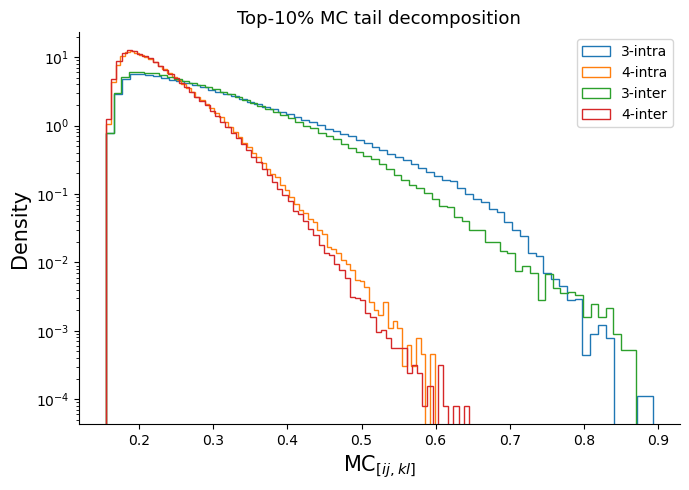

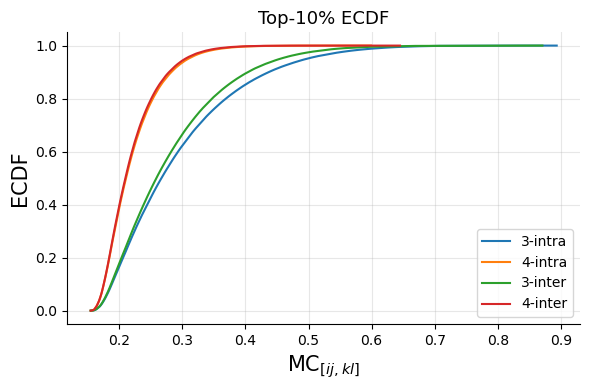

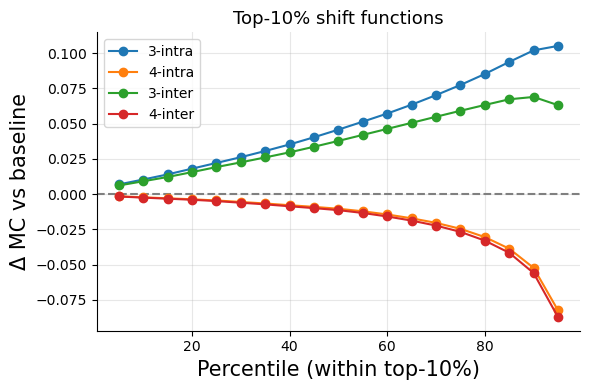

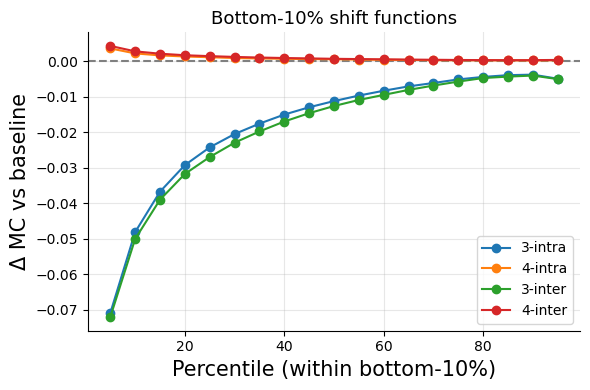

In [ ]:
#!/usr/bin/env python3
"""
MC trimer analysis – cleaned & stable version

Author: Samy
"""

# =============================================================================
# Imports
# =============================================================================
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from shared_code.fun_loaddata import load_timeseries_bundle
from shared_code.fun_paths import get_paths
from shared_code.fun_utils import set_figure_params

# =============================================================================
# Global plotting config
# =============================================================================
plt.rcParams.update({
    "axes.spines.right": False,
    "axes.spines.top": False,
    "axes.labelsize": 13,
    "axes.titlesize": 12,
})

save_fig = set_figure_params(True)

# =============================================================================
# Paths & data loading
# =============================================================================
paths = get_paths(
    dataset_name="ines_abdallah",
    timecourse_folder="Timecourses_updated_03052024",
    cognitive_data_file="ROIs.xlsx",
    anat_labels_file="41_Allen.txt",
)

bundle = load_timeseries_bundle(
    paths["preprocessed"] / "ts_and_meta_2m4m.npz",
    paths["preprocessed"] / "grouping_data_oip.pkl",
)

mc_mod_dir = paths["mc_mod"]
trimers_dir = paths["trimers"]
fig_dir = paths["f_motif"]
fig_dir.mkdir(exist_ok=True, parents=True)

mask_groups = bundle.mask_groups
label_variables = bundle.label_variables
n_animals = bundle.n_animals
regions = bundle.n_regions

# =============================================================================
# Load MC + trimer data
# =============================================================================
label_ref = "wt2m"
mc_file = mc_mod_dir / (
    f"mc_allegiance_ref(runs={label_ref}_gammaval=1000)=100_"
    f"lag=1_windowsize=7_animals={n_animals}_regions={regions}.npz"


)
mc = np.load(mc_file, allow_pickle=True)


mc_val = mc["mc_val_tril"]                    # (animals, edges)
mc_mod_idx = mc["mc_mod_idx"].squeeze()       # (edges,)
mc_idx = mc["mc_idx_tril"]

trimers = np.load(
    trimers_dir / (
        f"trimers_allegiance_ref(runs={label_ref}_gammaval=1000)=100_"




        f"lag=1_windowsize=7_animals={n_animals}_regions={regions}.npz"
    )
)
mc_nplets_index = trimers["nplets_index"]     # 0 = 4-plets, >0 = trimers

# =============================================================================
# Masks (centralized – DO NOT INLINE THESE)
# =============================================================================
EDGE = {
    "intra":  (mc_mod_idx > 0)[None, :],
    "inter":  (mc_mod_idx == 0)[None, :],
    "trimer": (mc_nplets_index > 0)[None, :],
    "tetra":  (mc_nplets_index == 0)[None, :],
}

def tail_mask(mc_val, q):
    """Per-animal percentile tail mask"""
    thr = np.nanpercentile(mc_val, q=q, axis=1)
    return mc_val <= thr[:, None] if q < 50 else mc_val >= thr[:, None]

TOP10 = tail_mask(mc_val, 90)
BOT10 = tail_mask(mc_val, 10)

# =============================================================================
# Safe extractor (NO broadcasting bugs)
# =============================================================================
def extract(mc_val, *masks):
    mask = np.ones_like(mc_val, dtype=bool)
    for m in masks:
        mask &= m
    return mc_val[mask]

# =============================================================================
# ECDF
# =============================================================================
def ecdf(x):
    x = np.asarray(x)
    x = x[np.isfinite(x)]
    x = np.sort(x)
    y = np.arange(1, len(x) + 1) / (len(x) + 1)
    return x, y

# =============================================================================
# Shift function
# =============================================================================
def shift(x_ref, x_cmp, pcts):
    return np.percentile(x_cmp, pcts) - np.percentile(x_ref, pcts)

PCTS = np.linspace(5, 95, 19)

# =============================================================================
# ---- TOP 10% ANALYSIS ----
# =============================================================================
x_base = extract(mc_val, TOP10)

x_sets = {
    "3-intra": extract(mc_val, TOP10, EDGE["trimer"], EDGE["intra"]),
    "4-intra": extract(mc_val, TOP10, EDGE["tetra"],  EDGE["intra"]),
    "3-inter": extract(mc_val, TOP10, EDGE["trimer"], EDGE["inter"]),
    "4-inter": extract(mc_val, TOP10, EDGE["tetra"],  EDGE["inter"]),
}

# --- Histogram ---
plt.figure(figsize=(7, 5))
for k, x in x_sets.items():
    plt.hist(x, bins=70, density=True, histtype="step", label=k)
plt.yscale("log")
plt.xlabel(r"MC$_{[ij,kl]}$")
plt.ylabel("Density")
plt.title("Top-10% MC tail decomposition")
plt.legend()
plt.tight_layout()
if save_fig:
    plt.savefig(fig_dir / "top10_hist.png")

# --- ECDF ---
plt.figure(figsize=(6, 4))
for k, x in x_sets.items():
    xs, ys = ecdf(x)
    plt.plot(xs, ys, label=k)
plt.xlabel(r"MC$_{[ij,kl]}$")
plt.ylabel("ECDF")
plt.title("Top-10% ECDF")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
if save_fig:
    plt.savefig(fig_dir / "top10_ecdf.png")

# --- Shift functions ---
plt.figure(figsize=(6, 4))
plt.axhline(0, color="gray", ls="--")
for k, x in x_sets.items():
    plt.plot(PCTS, shift(x_base, x, PCTS), marker="o", label=k)
plt.xlabel("Percentile (within top-10%)")
plt.ylabel("Δ MC vs baseline")
plt.title("Top-10% shift functions")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
if save_fig:
    plt.savefig(fig_dir / "top10_shift.png")

# =============================================================================
# ---- BOTTOM 10% ANALYSIS ----
# =============================================================================
x_base = extract(mc_val, BOT10)

x_sets = {
    "3-intra": extract(mc_val, BOT10, EDGE["trimer"], EDGE["intra"]),
    "4-intra": extract(mc_val, BOT10, EDGE["tetra"],  EDGE["intra"]),
    "3-inter": extract(mc_val, BOT10, EDGE["trimer"], EDGE["inter"]),
    "4-inter": extract(mc_val, BOT10, EDGE["tetra"],  EDGE["inter"]),
}

plt.figure(figsize=(6, 4))
plt.axhline(0, color="gray", ls="--")
for k, x in x_sets.items():
    plt.plot(PCTS, shift(x_base, x, PCTS), marker="o", label=k)
plt.xlabel("Percentile (within bottom-10%)")
plt.ylabel("Δ MC vs baseline")
plt.title("Bottom-10% shift functions")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
if save_fig:
    plt.savefig(fig_dir / "bottom10_shift.png")

print("✔ MC trimer analysis completed cleanly.")



In [ ]:
from tkinter import font
from turtle import title
import matplotlib.pyplot as plt
import numpy as np

# from functions_analysis import *
from shared_code.fun_loaddata import load_timeseries_bundle
from shared_code.fun_paths import get_paths
from shared_code.fun_utils import set_figure_params

# =============================================================================
# This code uses
#   cog_data_filtered, data_ts, grouping_data, and data_mc_mod

# Plot
# PLOT MC using allegiance reference
# Plot MC for each individual
# Plot MC intra/inter modular per group
# Plot MC intra/inter for each individual
# Plot MC modules for each individual
# plot MC modules per group
# =============================================================================

In [ ]:
# ========================== Figure parameters ================================
# Save options
plt.rcParams.update(
    {
        "axes.labelsize": 15,
        "axes.titlesize": 13,
        # 'axes.spines.left': False, 'axes.spines.bottom': False,
        "axes.spines.right": False,
        "axes.spines.top": False,
    }
)

title_groups = ('oip', 'nor', 'genotype', 'sex')

save_fig = set_figure_params(True)
bins_parameter = 200

In [ ]:
# =================== Paths and folders =======================================
# ----------------- Paths -----------------
timecourse_folder = "Timecourses_updated_03052024"

paths = get_paths(
    dataset_name="ines_abdallah",
    timecourse_folder=timecourse_folder,
    cognitive_data_file="ROIs.xlsx",
    anat_labels_file="41_Allen.txt",
)

bundle = load_timeseries_bundle(
    paths["preprocessed"] / "ts_and_meta_2m4m.npz",
    paths["preprocessed"] / "grouping_data_oip.pkl",
)

# ========================== Load data =========================
# ts data and metadata
ts = bundle.ts
n_animals = bundle.n_animals
regions = bundle.n_regions
anat_labels = bundle.anat_labels
is_2month_old = bundle.is_2month_old
total_tr = bundle.total_tr
# Grouping data
mask_groups = bundle.mask_groups
label_variables = bundle.label_variables

In [ ]:
# ========================= Create folders ================================
dataset_name = paths["results"].name
mc_mod_dir = paths["mc_mod"]  # same as in the other script
trimers_dir = paths["trimers"]
motif_fig_dir = paths["f_motif"]

for directory in (mc_mod_dir, trimers_dir, motif_fig_dir):
    directory.mkdir(parents=True, exist_ok=True)
folders = {"2mois": "TC_2months", "4mois": "TC_4months"}

In [ ]:
# Metaconnectivity
# =============================================================================
# Parameters speed

PROCESSORS = -1

lag = 1
tau = 5
window_size = 7
window_parameter = (5, 100, 1)

# Parameters allegiance analysis
n_runs_allegiance = 1000
gamma_pt_allegiance = 100
ind_ref = mask_groups[0][0]  # the mask of the reference matrix
# label_ref = label_variables[0][0] #The label of the reference matrix
# label_ref = "Good2m"  # The label of the reference matrix
label_ref = 'wt2m' #The label of the reference matrix

tau_array = np.append(np.arange(0, tau), tau)
lentau = len(tau_array)

time_window_min, time_window_max, time_window_step = window_parameter
time_window_range = np.arange(time_window_min, time_window_max + 1, time_window_step)

In [ ]:
# ----------------- Load MC (same naming as in MC script) -----------------
mc_data_filename = (
    f"mc_allegiance_ref(runs={label_ref}_gammaval={n_runs_allegiance})="
    f"{gamma_pt_allegiance}_lag={lag}_windowsize={window_size}_animals={n_animals}_regions={regions}.npz"
).replace(" ", "")

data_mc_mod_filename = mc_mod_dir / mc_data_filename
data_mc_mod = np.load(data_mc_mod_filename, allow_pickle=True)

mc_allegiance = data_mc_mod["mc"]
mc_ref_allegiance_communities = data_mc_mod["mc_ref_allegiance_communities"]
mc_val = data_mc_mod["mc_val_tril"]
mc_mod_idx = np.squeeze(data_mc_mod["mc_mod_idx"])
mc_reg_idx = data_mc_mod["mc_reg_idx"]
mc_idx = data_mc_mod["mc_idx_tril"]  # <-- add this line

# ----------------- Load trimers indices -----------------
trimers_filename = (
    f"trimers_allegiance_ref(runs={label_ref}_gammaval={n_runs_allegiance})="
    f"{gamma_pt_allegiance}_lag={lag}_windowsize={window_size}_animals={n_animals}_regions={regions}.npz"
).replace(" ", "")

trimers_path = trimers_dir / trimers_filename
trimers_load = np.load(trimers_path)
mc_nplets_index = trimers_load["nplets_index"]

In [ ]:
# =========================== Labels figures ==================================
label_mclinks = r"Inter-regional links"
label_mc_formula = r"MC$_{[ij, kl]} = CC[FC_{ij}(t), FC_{kl}(t)]$"
label_yhist = "Probability density"
label_mc_trimers = r"Trimer Meta-strengths $MC(i) = \sum_{jk} MC_{[ij, il]}$"

label_trimer = r"Trimer = MC$_{[ir, jr]}$"

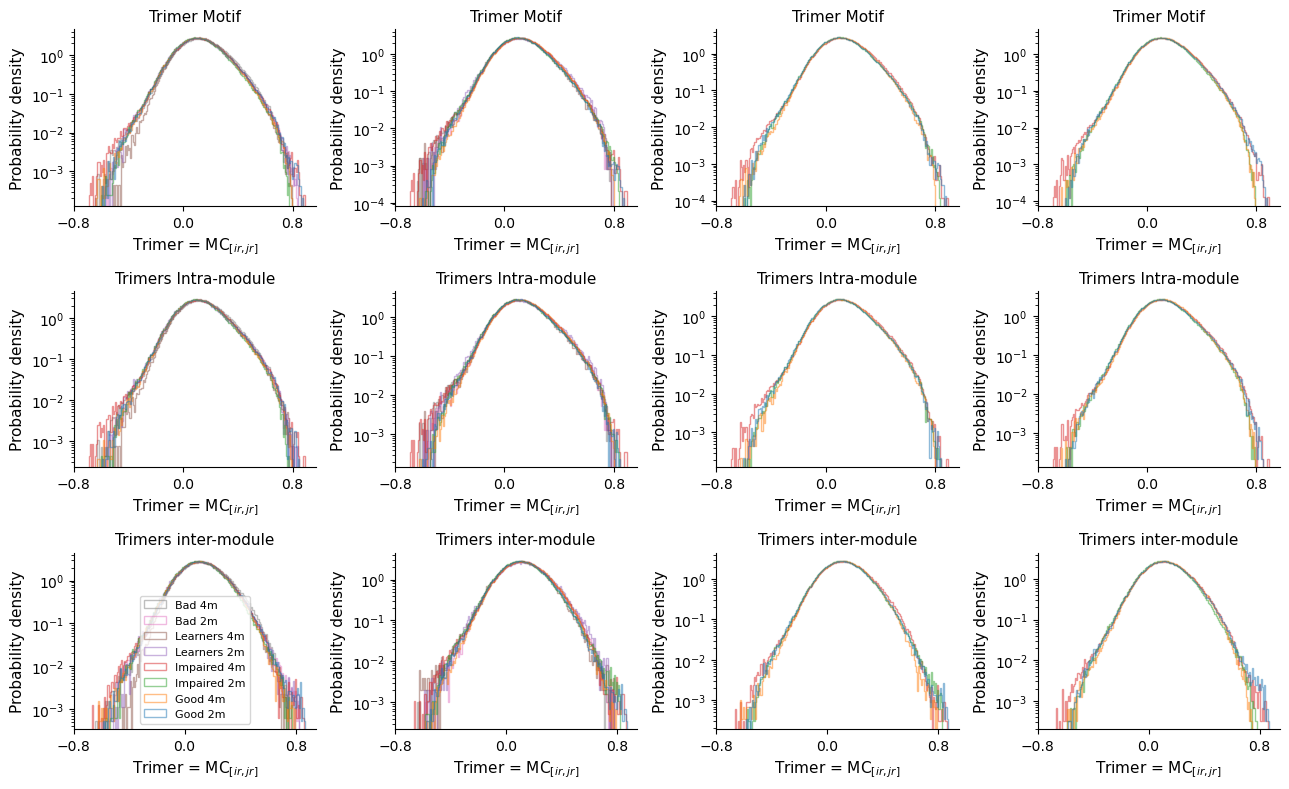

In [ ]:
# =============================================================================
# Plot MC trimer intra/inter per group
# =============================================================================
n_groups = len(mask_groups)

# plt.figure(1, figsize=(5 * n_groups, 13))
plt.figure(1, figsize=(13, 8))
plt.clf()

for idx, setb in enumerate(mask_groups):
    aux_label = label_variables[idx]

    # column index
    col = idx

    # --- Row 1: all trimers ---
    ax1 = plt.subplot(3, n_groups, 1 + col)
    ax1.set_title("Trimer Motif", fontsize=11)

    ax1.hist(
        [mc_val[mod][:, mc_nplets_index > 0].ravel() for mod in setb],
        histtype="step",
        bins=bins_parameter,
        density=True,
        label=aux_label,
        alpha=0.5,
    )
    ax1.set_yscale("log")
    ax1.set_ylabel(label_yhist, fontsize=11)
    ax1.set_xlabel(label_trimer, fontsize=11)
    ax1.set_xticks([-0.8, 0, 0.8])
    # ax1.set_ylim(1e-5, 1e0)

    # --- Row 2: intra-module trimers ---
    ax2 = plt.subplot(3, n_groups, 1 + n_groups + col)
    ax2.set_title("Trimers Intra-module", fontsize=11)

    ax2.hist(
        [
            mc_val[mod][:, (mc_nplets_index > 0) * (mc_mod_idx > 0)].ravel()
            for mod in setb
        ],
        histtype="step",
        bins=bins_parameter,
        density=True,
        label=aux_label,
        alpha=0.5,
    )
    ax2.set_yscale("log")
    ax2.set_ylabel(label_yhist, fontsize=11)
    ax2.set_xlabel(label_trimer, fontsize=11)
    ax2.set_xticks([-0.8, 0, 0.8])
    # ax2.set_ylim(1e-5, 1e0)

    # --- Row 3: inter-module trimers ---
    ax3 = plt.subplot(3, n_groups, 1 + 2 * n_groups + col)
    ax3.set_title("Trimers inter-module", fontsize=11)

    ax3.hist(
        [
            mc_val[mod][:, (mc_nplets_index > 0) * (mc_mod_idx == 0)].ravel()
            for mod in setb
        ],
        histtype="step",
        bins=bins_parameter,
        density=True,
        label=aux_label,
        alpha=0.5,
    )
    ax3.set_yscale("log")
    ax3.set_ylabel(label_yhist, fontsize=11)
    ax3.set_xlabel(label_trimer, fontsize=11)
    ax3.set_xticks([-0.8, 0, 0.8])
    # ax3.set_ylim(1e-5, 1e0)

# only one legend to avoid over-plotting
plt.subplot(3, n_groups, 1 + 2 * n_groups)  # bottom-left panel
plt.legend(fontsize=8)

plt.tight_layout()
if save_fig:
    plt.savefig(motif_fig_dir / "hist_trimer_mcvalues_mod(intra_inter).png")

No kernel connected

No kernel connected

No kernel connected

Connected to funsy (Python 3.13.3)

In [ ]:
#!/usr/bin/env python3
"""
MC trimer analysis – modular & reference-safe

Author: Samy
"""

# =============================================================================
# CONFIGURATION
# =============================================================================

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from shared_code.fun_loaddata import load_timeseries_bundle
from shared_code.fun_paths import get_paths
from shared_code.fun_utils import set_figure_params

# ---- plotting defaults ------------------------------------------------------
plt.rcParams.update(
    dict(
        axes.spines.right=False,
        axes.spines.top=False,
        axes.labelsize=13,
        axes.titlesize=12,
    )
)
SAVE_FIG = set_figure_params(True)

# ---- analysis constants -----------------------------------------------------
REF_GROUP = "wt 2m"
REF_BINS = np.linspace(-0.8, 1.0, 100)

# Authoritative group colors (DO NOT TOUCH elsewhere)
GROUP_COLORS = {
    "wt 2m": "#1f77b4",
    "wt 4m": "#ff7f0e",
    "dkl 2m": "#2ca02c",
    "dkl 4m": "#d62728",
}

# =============================================================================
# DATA LOADING
# =============================================================================

def load_all():
    paths = get_paths(
        dataset_name="ines_abdallah",
        timecourse_folder="Timecourses_updated_03052024",
        cognitive_data_file="ROIs.xlsx",
        anat_labels_file="41_Allen.txt",
    )

    bundle = load_timeseries_bundle(
        paths["preprocessed"] / "ts_and_meta_2m4m.npz",
        paths["preprocessed"] / "grouping_data_oip.pkl",
    )

    mc = np.load(
        paths["mc_mod"]
        / f"mc_allegiance_ref(runs=wt2m_gammaval=1000)=100_"
          f"lag=1_windowsize=7_animals={bundle.n_animals}_regions={bundle.n_regions}.npz",
        allow_pickle=True,
    )

    fig_dir = paths["f_motif"]
    fig_dir.mkdir(exist_ok=True, parents=True)

    return bundle, mc, fig_dir


# =============================================================================
# MASKS & HELPERS
# =============================================================================

def true_indices_nested(mask_groups):
    """Return list[group][indices]"""
    return [[np.flatnonzero(arr) for arr in group] for group in mask_groups]


def histogram_prob(x, bins):
    h, _ = np.histogram(x, bins=bins)
    p = h / h.sum() if h.sum() > 0 else np.zeros_like(h)
    return p


def delta_p(p_ref, p_cmp):
    """Symmetric ΔP with NaN safety"""
    dp = (p_ref - p_cmp) / (p_ref + p_cmp)
    return np.nan_to_num(dp, nan=0.0)


# =============================================================================
# CORE COMPUTATION
# =============================================================================

def compute_group_histograms(mc_val, indices_mask, labels):
    """
    Returns:
        probs[label] -> probability histogram
    """
    probs = {}

    for idx, inds in enumerate(indices_mask):
        label = labels[idx]
        mc_subset = mc_val[inds, :].ravel()
        probs[label] = histogram_prob(mc_subset, REF_BINS)

    return probs


# =============================================================================
# PLOTTING
# =============================================================================

def plot_histograms(p_all, p_groups, fig_dir):
    fig, ax = plt.subplots(figsize=(7, 5))

    ax.plot(
        REF_BINS[:-1], p_all,
        color="black", lw=2, label="All animals"
    )

    for label, p in p_groups.items():
        ax.plot(
            REF_BINS[:-1], p,
            color=GROUP_COLORS[label],
            label=label,
        )

    ax.set_yscale("log")
    ax.set_xlabel("MC values")
    ax.set_ylabel("Probability")
    ax.set_title("Histogram of MC values")
    ax.legend()

    fig.tight_layout()
    if SAVE_FIG:
        fig.savefig(fig_dir / "mc_histograms.png")


def plot_deltaP(p_ref, p_groups, fig_dir):
    fig, ax = plt.subplots(figsize=(7, 5))

    for label, p in p_groups.items():
        if label == REF_GROUP:
            continue

        ax.plot(
            REF_BINS[:-1],
            delta_p(p_ref, p),
            color=GROUP_COLORS[label],
            alpha=0.8,
            label=label,
        )

    ax.axhline(0, color="black", lw=1)
    ax.set_xlabel("MC values")
    ax.set_ylabel("ΔP vs wt 2m")
    ax.set_title("ΔP histogram (reference = wt 2m)")
    ax.legend()

    fig.tight_layout()
    if SAVE_FIG:
        fig.savefig(fig_dir / "mc_deltaP.png")


# =============================================================================
# MAIN
# =============================================================================

def main():
    bundle, mc, fig_dir = load_all()

    mc_val = mc["mc_val_tril"]
    indices_mask = true_indices_nested(bundle.mask_groups)[2]  # same as before
    labels = bundle.label_variables[2]

    # ---- compute ------------------------------------------------------------
    p_all = histogram_prob(mc_val.ravel(), REF_BINS)
    p_groups = compute_group_histograms(mc_val, indices_mask, labels)

    # ---- plots --------------------------------------------------------------
    plot_histograms(p_all, p_groups, fig_dir)
    plot_deltaP(p_groups[REF_GROUP], p_groups, fig_dir)


if __name__ == "__main__":
    main()



SyntaxError: expression cannot contain assignment, perhaps you meant "=="? (<ipython-input-1-c8a802eb6e45>, line 23)

In [ ]:
#!/usr/bin/env python3
"""
MC trimer analysis – modular & reference-safe

Author: Samy
"""

# =============================================================================
# CONFIGURATION
# =============================================================================

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from shared_code.fun_loaddata import load_timeseries_bundle
from shared_code.fun_paths import get_paths
from shared_code.fun_utils import set_figure_params

# ---- plotting defaults ------------------------------------------------------
plt.rcParams.update(
    dict(
        axes.spines.right=False,
        axes.spines.top=False,
        axes.labelsize=13,
        axes.titlesize=12,
    )
)
SAVE_FIG = set_figure_params(True)

# ---- analysis constants -----------------------------------------------------
REF_GROUP = "wt 2m"
REF_BINS = np.linspace(-0.8, 1.0, 100)

# Authoritative group colors (DO NOT TOUCH elsewhere)
GROUP_COLORS = {
    "wt 2m": "#1f77b4",
    "wt 4m": "#ff7f0e",
    "dkl 2m": "#2ca02c",
    "dkl 4m": "#d62728",
}

# =============================================================================
# DATA LOADING
# =============================================================================

def load_all():
    paths = get_paths(
        dataset_name="ines_abdallah",
        timecourse_folder="Timecourses_updated_03052024",
        cognitive_data_file="ROIs.xlsx",
        anat_labels_file="41_Allen.txt",
    )

    bundle = load_timeseries_bundle(
        paths["preprocessed"] / "ts_and_meta_2m4m.npz",
        paths["preprocessed"] / "grouping_data_oip.pkl",
    )

    mc = np.load(
        paths["mc_mod"]
        / f"mc_allegiance_ref(runs=wt2m_gammaval=1000)=100_"
          f"lag=1_windowsize=7_animals={bundle.n_animals}_regions={bundle.n_regions}.npz",
        allow_pickle=True,
    )

    fig_dir = paths["f_motif"]
    fig_dir.mkdir(exist_ok=True, parents=True)

    return bundle, mc, fig_dir


# =============================================================================
# MASKS & HELPERS
# =============================================================================

def true_indices_nested(mask_groups):
    """Return list[group][indices]"""
    return [[np.flatnonzero(arr) for arr in group] for group in mask_groups]


def histogram_prob(x, bins):
    h, _ = np.histogram(x, bins=bins)
    p = h / h.sum() if h.sum() > 0 else np.zeros_like(h)
    return p


def delta_p(p_ref, p_cmp):
    """Symmetric ΔP with NaN safety"""
    dp = (p_ref - p_cmp) / (p_ref + p_cmp)
    return np.nan_to_num(dp, nan=0.0)


# =============================================================================
# CORE COMPUTATION
# =============================================================================

def compute_group_histograms(mc_val, indices_mask, labels):
    """
    Returns:
        probs[label] -> probability histogram
    """
    probs = {}

    for idx, inds in enumerate(indices_mask):
        label = labels[idx]
        mc_subset = mc_val[inds, :].ravel()
        probs[label] = histogram_prob(mc_subset, REF_BINS)

    return probs


# =============================================================================
# PLOTTING
# =============================================================================

def plot_histograms(p_all, p_groups, fig_dir):
    fig, ax = plt.subplots(figsize=(7, 5))

    ax.plot(
        REF_BINS[:-1], p_all,
        color="black", lw=2, label="All animals"
    )

    for label, p in p_groups.items():
        ax.plot(
            REF_BINS[:-1], p,
            color=GROUP_COLORS[label],
            label=label,
        )

    ax.set_yscale("log")
    ax.set_xlabel("MC values")
    ax.set_ylabel("Probability")
    ax.set_title("Histogram of MC values")
    ax.legend()

    fig.tight_layout()
    if SAVE_FIG:
        fig.savefig(fig_dir / "mc_histograms.png")


def plot_deltaP(p_ref, p_groups, fig_dir):
    fig, ax = plt.subplots(figsize=(7, 5))

    for label, p in p_groups.items():
        if label == REF_GROUP:
            continue

        ax.plot(
            REF_BINS[:-1],
            delta_p(p_ref, p),
            color=GROUP_COLORS[label],
            alpha=0.8,
            label=label,
        )

    ax.axhline(0, color="black", lw=1)
    ax.set_xlabel("MC values")
    ax.set_ylabel("ΔP vs wt 2m")
    ax.set_title("ΔP histogram (reference = wt 2m)")
    ax.legend()

    fig.tight_layout()
    if SAVE_FIG:
        fig.savefig(fig_dir / "mc_deltaP.png")


# =============================================================================
# MAIN
# =============================================================================

def main():
    bundle, mc, fig_dir = load_all()

    mc_val = mc["mc_val_tril"]
    indices_mask = true_indices_nested(bundle.mask_groups)[2]  # same as before
    labels = bundle.label_variables[2]

    # ---- compute ------------------------------------------------------------
    p_all = histogram_prob(mc_val.ravel(), REF_BINS)
    p_groups = compute_group_histograms(mc_val, indices_mask, labels)

    # ---- plots --------------------------------------------------------------
    plot_histograms(p_all, p_groups, fig_dir)
    plot_deltaP(p_groups[REF_GROUP], p_groups, fig_dir)


if __name__ == "__main__":
    main()



SyntaxError: expression cannot contain assignment, perhaps you meant "=="? (<ipython-input-2-c8a802eb6e45>, line 23)

In [ ]:
#!/usr/bin/env python3
"""
MC trimer analysis – modular & reference-safe

Author: Samy
"""

# =============================================================================
# CONFIGURATION
# =============================================================================

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from shared_code.fun_loaddata import load_timeseries_bundle
from shared_code.fun_paths import get_paths
from shared_code.fun_utils import set_figure_params

# ---- plotting defaults ------------------------------------------------------
plt.rcParams.update(
plt.rcParams.update(
    {
        "axes.spines.right": False,
        "axes.spines.top": False,
        "axes.labelsize": 13,
        "axes.titlesize": 12,
    }
)


)
SAVE_FIG = set_figure_params(True)

# ---- analysis constants -----------------------------------------------------
REF_GROUP = "wt 2m"
REF_BINS = np.linspace(-0.8, 1.0, 100)

# Authoritative group colors (DO NOT TOUCH elsewhere)
GROUP_COLORS = {
    "wt 2m": "#1f77b4",
    "wt 4m": "#ff7f0e",
    "dkl 2m": "#2ca02c",
    "dkl 4m": "#d62728",
}

# =============================================================================
# DATA LOADING
# =============================================================================

def load_all():
    paths = get_paths(
        dataset_name="ines_abdallah",
        timecourse_folder="Timecourses_updated_03052024",
        cognitive_data_file="ROIs.xlsx",
        anat_labels_file="41_Allen.txt",
    )

    bundle = load_timeseries_bundle(
        paths["preprocessed"] / "ts_and_meta_2m4m.npz",
        paths["preprocessed"] / "grouping_data_oip.pkl",
    )

    mc = np.load(
        paths["mc_mod"]
        / f"mc_allegiance_ref(runs=wt2m_gammaval=1000)=100_"
          f"lag=1_windowsize=7_animals={bundle.n_animals}_regions={bundle.n_regions}.npz",
        allow_pickle=True,
    )

    fig_dir = paths["f_motif"]
    fig_dir.mkdir(exist_ok=True, parents=True)

    return bundle, mc, fig_dir


# =============================================================================
# MASKS & HELPERS
# =============================================================================

def true_indices_nested(mask_groups):
    """Return list[group][indices]"""
    return [[np.flatnonzero(arr) for arr in group] for group in mask_groups]


def histogram_prob(x, bins):
    h, _ = np.histogram(x, bins=bins)
    p = h / h.sum() if h.sum() > 0 else np.zeros_like(h)
    return p


def delta_p(p_ref, p_cmp):
    """Symmetric ΔP with NaN safety"""
    dp = (p_ref - p_cmp) / (p_ref + p_cmp)
    return np.nan_to_num(dp, nan=0.0)


# =============================================================================
# CORE COMPUTATION
# =============================================================================

def compute_group_histograms(mc_val, indices_mask, labels):
    """
    Returns:
        probs[label] -> probability histogram
    """
    probs = {}

    for idx, inds in enumerate(indices_mask):
        label = labels[idx]
        mc_subset = mc_val[inds, :].ravel()
        probs[label] = histogram_prob(mc_subset, REF_BINS)

    return probs


# =============================================================================
# PLOTTING
# =============================================================================

def plot_histograms(p_all, p_groups, fig_dir):
    fig, ax = plt.subplots(figsize=(7, 5))

    ax.plot(
        REF_BINS[:-1], p_all,
        color="black", lw=2, label="All animals"
    )

    for label, p in p_groups.items():
        ax.plot(
            REF_BINS[:-1], p,
            color=GROUP_COLORS[label],
            label=label,
        )

    ax.set_yscale("log")
    ax.set_xlabel("MC values")
    ax.set_ylabel("Probability")
    ax.set_title("Histogram of MC values")
    ax.legend()

    fig.tight_layout()
    if SAVE_FIG:
        fig.savefig(fig_dir / "mc_histograms.png")


def plot_deltaP(p_ref, p_groups, fig_dir):
    fig, ax = plt.subplots(figsize=(7, 5))

    for label, p in p_groups.items():
        if label == REF_GROUP:
            continue

        ax.plot(
            REF_BINS[:-1],
            delta_p(p_ref, p),
            color=GROUP_COLORS[label],
            alpha=0.8,
            label=label,
        )

    ax.axhline(0, color="black", lw=1)
    ax.set_xlabel("MC values")
    ax.set_ylabel("ΔP vs wt 2m")
    ax.set_title("ΔP histogram (reference = wt 2m)")
    ax.legend()

    fig.tight_layout()
    if SAVE_FIG:
        fig.savefig(fig_dir / "mc_deltaP.png")


# =============================================================================
# MAIN
# =============================================================================

def main():
    bundle, mc, fig_dir = load_all()

    mc_val = mc["mc_val_tril"]
    indices_mask = true_indices_nested(bundle.mask_groups)[2]  # same as before
    labels = bundle.label_variables[2]

    # ---- compute ------------------------------------------------------------
    p_all = histogram_prob(mc_val.ravel(), REF_BINS)
    p_groups = compute_group_histograms(mc_val, indices_mask, labels)

    # ---- plots --------------------------------------------------------------
    plot_histograms(p_all, p_groups, fig_dir)
    plot_deltaP(p_groups[REF_GROUP], p_groups, fig_dir)


if __name__ == "__main__":
    main()



[info] Using PATHS_ROOT=/media/samy/Elements2/Proyectos/LauraHarsan


TypeError: 'NoneType' object is not iterable

KeyError: 'dKI 2m'

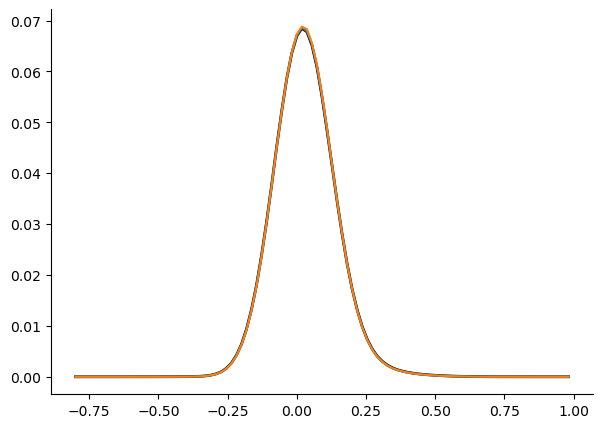

In [ ]:
#!/usr/bin/env python3
"""
MC trimer analysis – modular & reference-safe

Author: Samy
"""

# =============================================================================
# CONFIGURATION
# =============================================================================

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from shared_code.fun_loaddata import load_timeseries_bundle
from shared_code.fun_paths import get_paths
from shared_code.fun_utils import set_figure_params

# ---- plotting defaults ------------------------------------------------------
plt.rcParams.update(
    {
        "axes.spines.right": False,
        "axes.spines.top": False,
        "axes.labelsize": 13,
        "axes.titlesize": 12,
    }
)


SAVE_FIG = set_figure_params(True)

# ---- analysis constants -----------------------------------------------------
REF_GROUP = "wt 2m"
REF_BINS = np.linspace(-0.8, 1.0, 100)

# Authoritative group colors (DO NOT TOUCH elsewhere)
GROUP_COLORS = {
    "wt 2m": "#1f77b4",
    "wt 4m": "#ff7f0e",
    "dkl 2m": "#2ca02c",
    "dkl 4m": "#d62728",
}

# =============================================================================
# DATA LOADING
# =============================================================================

def load_all():
    paths = get_paths(
        dataset_name="ines_abdallah",
        timecourse_folder="Timecourses_updated_03052024",
        cognitive_data_file="ROIs.xlsx",
        anat_labels_file="41_Allen.txt",
    )

    bundle = load_timeseries_bundle(
        paths["preprocessed"] / "ts_and_meta_2m4m.npz",
        paths["preprocessed"] / "grouping_data_oip.pkl",
    )

    mc = np.load(
        paths["mc_mod"]
        / f"mc_allegiance_ref(runs=wt2m_gammaval=1000)=100_"
          f"lag=1_windowsize=7_animals={bundle.n_animals}_regions={bundle.n_regions}.npz",
        allow_pickle=True,
    )

    fig_dir = paths["f_motif"]
    fig_dir.mkdir(exist_ok=True, parents=True)

    return bundle, mc, fig_dir


# =============================================================================
# MASKS & HELPERS
# =============================================================================

def true_indices_nested(mask_groups):
    """Return list[group][indices]"""
    return [[np.flatnonzero(arr) for arr in group] for group in mask_groups]


def histogram_prob(x, bins):
    h, _ = np.histogram(x, bins=bins)
    p = h / h.sum() if h.sum() > 0 else np.zeros_like(h)
    return p


def delta_p(p_ref, p_cmp):
    """Symmetric ΔP with NaN safety"""
    dp = (p_ref - p_cmp) / (p_ref + p_cmp)
    return np.nan_to_num(dp, nan=0.0)


# =============================================================================
# CORE COMPUTATION
# =============================================================================

def compute_group_histograms(mc_val, indices_mask, labels):
    """
    Returns:
        probs[label] -> probability histogram
    """
    probs = {}

    for idx, inds in enumerate(indices_mask):
        label = labels[idx]
        mc_subset = mc_val[inds, :].ravel()
        probs[label] = histogram_prob(mc_subset, REF_BINS)

    return probs


# =============================================================================
# PLOTTING
# =============================================================================

def plot_histograms(p_all, p_groups, fig_dir):
    fig, ax = plt.subplots(figsize=(7, 5))

    ax.plot(
        REF_BINS[:-1], p_all,
        color="black", lw=2, label="All animals"
    )

    for label, p in p_groups.items():
        ax.plot(
            REF_BINS[:-1], p,
            color=GROUP_COLORS[label],
            label=label,
        )

    ax.set_yscale("log")
    ax.set_xlabel("MC values")
    ax.set_ylabel("Probability")
    ax.set_title("Histogram of MC values")
    ax.legend()

    fig.tight_layout()
    if SAVE_FIG:
        fig.savefig(fig_dir / "mc_histograms.png")


def plot_deltaP(p_ref, p_groups, fig_dir):
    fig, ax = plt.subplots(figsize=(7, 5))

    for label, p in p_groups.items():
        if label == REF_GROUP:
            continue

        ax.plot(
            REF_BINS[:-1],
            delta_p(p_ref, p),
            color=GROUP_COLORS[label],
            alpha=0.8,
            label=label,
        )

    ax.axhline(0, color="black", lw=1)
    ax.set_xlabel("MC values")
    ax.set_ylabel("ΔP vs wt 2m")
    ax.set_title("ΔP histogram (reference = wt 2m)")
    ax.legend()

    fig.tight_layout()
    if SAVE_FIG:
        fig.savefig(fig_dir / "mc_deltaP.png")


# =============================================================================
# MAIN
# =============================================================================

def main():
    bundle, mc, fig_dir = load_all()

    mc_val = mc["mc_val_tril"]
    indices_mask = true_indices_nested(bundle.mask_groups)[2]  # same as before
    labels = bundle.label_variables[2]

    # ---- compute ------------------------------------------------------------
    p_all = histogram_prob(mc_val.ravel(), REF_BINS)
    p_groups = compute_group_histograms(mc_val, indices_mask, labels)

    # ---- plots --------------------------------------------------------------
    plot_histograms(p_all, p_groups, fig_dir)
    plot_deltaP(p_groups[REF_GROUP], p_groups, fig_dir)


if __name__ == "__main__":
    main()



KeyError: 'dKI 2m'

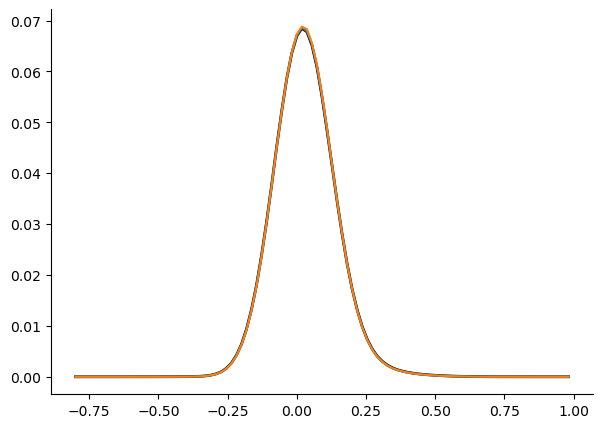

In [ ]:
#!/usr/bin/env python3
"""
MC trimer analysis – modular & reference-safe

Author: Samy
"""

# =============================================================================
# CONFIGURATION
# =============================================================================

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from shared_code.fun_loaddata import load_timeseries_bundle
from shared_code.fun_paths import get_paths
from shared_code.fun_utils import set_figure_params

# ---- plotting defaults ------------------------------------------------------
plt.rcParams.update(
    {
        "axes.spines.right": False,
        "axes.spines.top": False,
        "axes.labelsize": 13,
        "axes.titlesize": 12,
    }
)


SAVE_FIG = set_figure_params(True)

# ---- analysis constants -----------------------------------------------------
REF_GROUP = "wt 2m"
REF_BINS = np.linspace(-0.8, 1.0, 100)

# Authoritative group colors (DO NOT TOUCH elsewhere)
GROUP_COLORS = {
    "wt 2m": "#1f77b4",
    "wt 4m": "#ff7f0e",
    "dkl 2m": "#2ca02c",
    "dkl 4m": "#d62728",
}

# =============================================================================
# DATA LOADING
# =============================================================================

def load_all():
    paths = get_paths(
        dataset_name="ines_abdallah",
        timecourse_folder="Timecourses_updated_03052024",
        cognitive_data_file="ROIs.xlsx",
        anat_labels_file="41_Allen.txt",
    )

    bundle = load_timeseries_bundle(
        paths["preprocessed"] / "ts_and_meta_2m4m.npz",
        paths["preprocessed"] / "grouping_data_oip.pkl",
    )

    mc = np.load(
        paths["mc_mod"]
        / f"mc_allegiance_ref(runs=wt2m_gammaval=1000)=100_"
          f"lag=1_windowsize=7_animals={bundle.n_animals}_regions={bundle.n_regions}.npz",
        allow_pickle=True,
    )

    fig_dir = paths["f_motif"]
    fig_dir.mkdir(exist_ok=True, parents=True)

    return bundle, mc, fig_dir



# =============================================================================
# MASKS & HELPERS
# =============================================================================

def true_indices_nested(mask_groups):
    """Return list[group][indices]"""
    return [[np.flatnonzero(arr) for arr in group] for group in mask_groups]


def histogram_prob(x, bins):
    h, _ = np.histogram(x, bins=bins)
    p = h / h.sum() if h.sum() > 0 else np.zeros_like(h)
    return p


def delta_p(p_ref, p_cmp):
    """Symmetric ΔP with NaN safety"""
    dp = (p_ref - p_cmp) / (p_ref + p_cmp)
    return np.nan_to_num(dp, nan=0.0)


# =============================================================================
# CORE COMPUTATION
# =============================================================================

def compute_group_histograms(mc_val, indices_mask, labels):
    """
    Returns:
        probs[label] -> probability histogram
    """
    probs = {}

    for idx, inds in enumerate(indices_mask):
        label = labels[idx]
        mc_subset = mc_val[inds, :].ravel()
        probs[label] = histogram_prob(mc_subset, REF_BINS)

    return probs


# =============================================================================
# PLOTTING
# =============================================================================

def plot_histograms(p_all, p_groups, fig_dir):
    fig, ax = plt.subplots(figsize=(7, 5))

    ax.plot(
        REF_BINS[:-1], p_all,
        color="black", lw=2, label="All animals"
    )

    for label, p in p_groups.items():
        ax.plot(
            REF_BINS[:-1], p,
            color=GROUP_COLORS[label],
            label=label,
        )

    ax.set_yscale("log")
    ax.set_xlabel("MC values")
    ax.set_ylabel("Probability")
    ax.set_title("Histogram of MC values")
    ax.legend()

    fig.tight_layout()
    if SAVE_FIG:
        fig.savefig(fig_dir / "mc_histograms.png")


def plot_deltaP(p_ref, p_groups, fig_dir):
    fig, ax = plt.subplots(figsize=(7, 5))

    for label, p in p_groups.items():
        if label == REF_GROUP:
            continue

        ax.plot(
            REF_BINS[:-1],
            delta_p(p_ref, p),
            color=GROUP_COLORS[label],
            alpha=0.8,
            label=label,
        )

    ax.axhline(0, color="black", lw=1)
    ax.set_xlabel("MC values")
    ax.set_ylabel("ΔP vs wt 2m")
    ax.set_title("ΔP histogram (reference = wt 2m)")
    ax.legend()

    fig.tight_layout()
    if SAVE_FIG:
        fig.savefig(fig_dir / "mc_deltaP.png")


# =============================================================================
# MAIN
# =============================================================================

def main():
    bundle, mc, fig_dir = load_all()

    mc_val = mc["mc_val_tril"]
    indices_mask = true_indices_nested(bundle.mask_groups)[2]  # same as before
    labels = bundle.label_variables[2]

    # ---- compute ------------------------------------------------------------
    p_all = histogram_prob(mc_val.ravel(), REF_BINS)
    p_groups = compute_group_histograms(mc_val, indices_mask, labels)

    # ---- plots --------------------------------------------------------------
    plot_histograms(p_all, p_groups, fig_dir)
    plot_deltaP(p_groups[REF_GROUP], p_groups, fig_dir)


if __name__ == "__main__":
    main()



KeyError: 'dKI 2m'

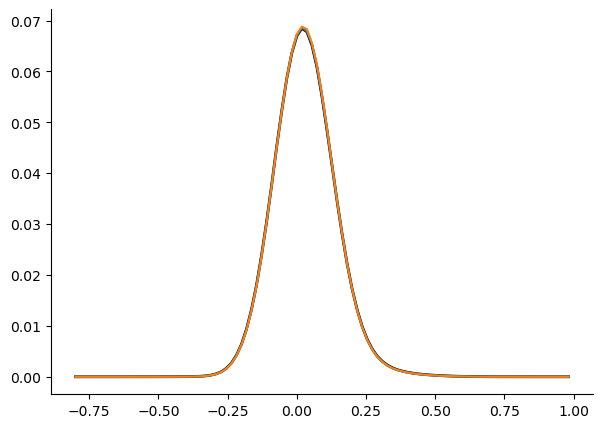

In [ ]:
#!/usr/bin/env python3
"""
MC trimer analysis – modular & reference-safe

Author: Samy
"""

# =============================================================================
# CONFIGURATION
# =============================================================================

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from shared_code.fun_loaddata import load_timeseries_bundle
from shared_code.fun_paths import get_paths
from shared_code.fun_utils import set_figure_params

# ---- plotting defaults ------------------------------------------------------
plt.rcParams.update(
    {
        "axes.spines.right": False,
        "axes.spines.top": False,
        "axes.labelsize": 13,
        "axes.titlesize": 12,
    }
)


SAVE_FIG = set_figure_params(True)

# ---- analysis constants -----------------------------------------------------
REF_GROUP = "wt 2m"
REF_BINS = np.linspace(-0.8, 1.0, 100)

# Authoritative group colors (DO NOT TOUCH elsewhere)
GROUP_COLORS = {
    "wt 2m": "#1f77b4",
    "wt 4m": "#ff7f0e",
    "dkl 2m": "#2ca02c",
    "dkl 4m": "#d62728",
}

# =============================================================================
# DATA LOADING
# =============================================================================

def load_all():
    paths = get_paths(
        dataset_name="ines_abdallah",
        timecourse_folder="Timecourses_updated_03052024",
        cognitive_data_file="ROIs.xlsx",
        anat_labels_file="41_Allen.txt",
    )

    bundle = load_timeseries_bundle(
        paths["preprocessed"] / "ts_and_meta_2m4m.npz",
        paths["preprocessed"] / "grouping_data_oip.pkl",
    )

    mc = np.load(
        paths["mc_mod"]
        / f"mc_allegiance_ref(runs=wt2m_gammaval=1000)=100_"
          f"lag=1_windowsize=7_animals={bundle.n_animals}_regions={bundle.n_regions}.npz",
        allow_pickle=True,
    )

    fig_dir = paths["f_motif"]
    fig_dir.mkdir(exist_ok=True, parents=True)

    return bundle, mc, fig_dir

def normalize_label(label: str) -> str:
    """
    Normalize group labels coming from bundle.label_variables
    to canonical form used in GROUP_COLORS.
    """
    return (
        label
        .strip()
        .lower()
        .replace("dki", "dkl")
        .replace("  ", " ")
    )



# =============================================================================
# MASKS & HELPERS
# =============================================================================

def true_indices_nested(mask_groups):
    """Return list[group][indices]"""
    return [[np.flatnonzero(arr) for arr in group] for group in mask_groups]


def histogram_prob(x, bins):
    h, _ = np.histogram(x, bins=bins)
    p = h / h.sum() if h.sum() > 0 else np.zeros_like(h)
    return p


def delta_p(p_ref, p_cmp):
    """Symmetric ΔP with NaN safety"""
    dp = (p_ref - p_cmp) / (p_ref + p_cmp)
    return np.nan_to_num(dp, nan=0.0)


# =============================================================================
# CORE COMPUTATION
# =============================================================================

def compute_group_histograms(mc_val, indices_mask, labels):
    """
    Returns:
        probs[label] -> probability histogram
    """
    probs = {}

    for idx, inds in enumerate(indices_mask):
        label = labels[idx]
        mc_subset = mc_val[inds, :].ravel()
        probs[label] = histogram_prob(mc_subset, REF_BINS)

    return probs


# =============================================================================
# PLOTTING
# =============================================================================

def plot_histograms(p_all, p_groups, fig_dir):
    fig, ax = plt.subplots(figsize=(7, 5))

    ax.plot(
        REF_BINS[:-1], p_all,
        color="black", lw=2, label="All animals"
    )

    for label, p in p_groups.items():
        ax.plot(
            REF_BINS[:-1], p,
            color=GROUP_COLORS[label],
            label=label,
        )

    ax.set_yscale("log")
    ax.set_xlabel("MC values")
    ax.set_ylabel("Probability")
    ax.set_title("Histogram of MC values")
    ax.legend()

    fig.tight_layout()
    if SAVE_FIG:
        fig.savefig(fig_dir / "mc_histograms.png")


def plot_deltaP(p_ref, p_groups, fig_dir):
    fig, ax = plt.subplots(figsize=(7, 5))

    for label, p in p_groups.items():
        if label == REF_GROUP:
            continue

        ax.plot(
            REF_BINS[:-1],
            delta_p(p_ref, p),
            color=GROUP_COLORS[label],
            alpha=0.8,
            label=label,
        )

    ax.axhline(0, color="black", lw=1)
    ax.set_xlabel("MC values")
    ax.set_ylabel("ΔP vs wt 2m")
    ax.set_title("ΔP histogram (reference = wt 2m)")
    ax.legend()

    fig.tight_layout()
    if SAVE_FIG:
        fig.savefig(fig_dir / "mc_deltaP.png")


# =============================================================================
# MAIN
# =============================================================================

def main():
    bundle, mc, fig_dir = load_all()

    mc_val = mc["mc_val_tril"]
    indices_mask = true_indices_nested(bundle.mask_groups)[2]  # same as before
    labels = bundle.label_variables[2]

    # ---- compute ------------------------------------------------------------
    p_all = histogram_prob(mc_val.ravel(), REF_BINS)
    p_groups = compute_group_histograms(mc_val, indices_mask, labels)

    # ---- plots --------------------------------------------------------------
    plot_histograms(p_all, p_groups, fig_dir)
    plot_deltaP(p_groups[REF_GROUP], p_groups, fig_dir)


if __name__ == "__main__":
    main()



<ipython-input-7-cbb146c17fed>:106: RuntimeWarning: invalid value encountered in divide
  dp = (p_ref - p_cmp) / (p_ref + p_cmp)


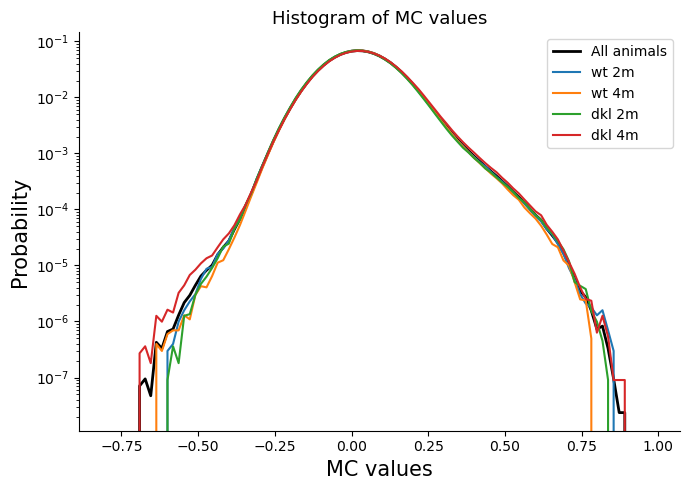

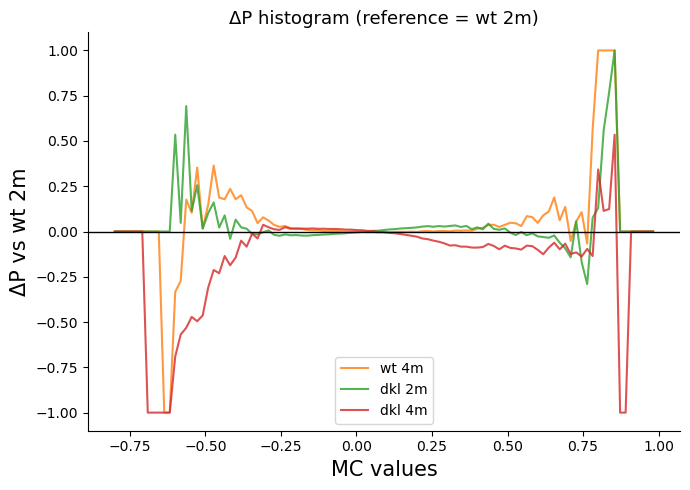

In [ ]:
#!/usr/bin/env python3
"""
MC trimer analysis – modular & reference-safe

Author: Samy
"""

# =============================================================================
# CONFIGURATION
# =============================================================================

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from shared_code.fun_loaddata import load_timeseries_bundle
from shared_code.fun_paths import get_paths
from shared_code.fun_utils import set_figure_params

# ---- plotting defaults ------------------------------------------------------
plt.rcParams.update(
    {
        "axes.spines.right": False,
        "axes.spines.top": False,
        "axes.labelsize": 13,
        "axes.titlesize": 12,
    }
)


SAVE_FIG = set_figure_params(True)

# ---- analysis constants -----------------------------------------------------
REF_GROUP = "wt 2m"
REF_BINS = np.linspace(-0.8, 1.0, 100)

# Authoritative group colors (DO NOT TOUCH elsewhere)
GROUP_COLORS = {
    "wt 2m": "#1f77b4",
    "wt 4m": "#ff7f0e",
    "dkl 2m": "#2ca02c",
    "dkl 4m": "#d62728",
}

# =============================================================================
# DATA LOADING
# =============================================================================

def load_all():
    paths = get_paths(
        dataset_name="ines_abdallah",
        timecourse_folder="Timecourses_updated_03052024",
        cognitive_data_file="ROIs.xlsx",
        anat_labels_file="41_Allen.txt",
    )

    bundle = load_timeseries_bundle(
        paths["preprocessed"] / "ts_and_meta_2m4m.npz",
        paths["preprocessed"] / "grouping_data_oip.pkl",
    )

    mc = np.load(
        paths["mc_mod"]
        / f"mc_allegiance_ref(runs=wt2m_gammaval=1000)=100_"
          f"lag=1_windowsize=7_animals={bundle.n_animals}_regions={bundle.n_regions}.npz",
        allow_pickle=True,
    )

    fig_dir = paths["f_motif"]
    fig_dir.mkdir(exist_ok=True, parents=True)

    return bundle, mc, fig_dir

def normalize_label(label: str) -> str:
    """
    Normalize group labels coming from bundle.label_variables
    to canonical form used in GROUP_COLORS.
    """
    return (
        label
        .strip()
        .lower()
        .replace("dki", "dkl")
        .replace("  ", " ")
    )



# =============================================================================
# MASKS & HELPERS
# =============================================================================

def true_indices_nested(mask_groups):
    """Return list[group][indices]"""
    return [[np.flatnonzero(arr) for arr in group] for group in mask_groups]


def histogram_prob(x, bins):
    h, _ = np.histogram(x, bins=bins)
    p = h / h.sum() if h.sum() > 0 else np.zeros_like(h)
    return p


def delta_p(p_ref, p_cmp):
    """Symmetric ΔP with NaN safety"""
    dp = (p_ref - p_cmp) / (p_ref + p_cmp)
    return np.nan_to_num(dp, nan=0.0)


# =============================================================================
# CORE COMPUTATION
# =============================================================================

def compute_group_histograms(mc_val, indices_mask, labels):
    """
    Returns:
        probs[label] -> probability histogram
    """
    probs = {}

    for idx, inds in enumerate(indices_mask):
        label = normalize_label(labels[idx])


        mc_subset = mc_val[inds, :].ravel()
        probs[label] = histogram_prob(mc_subset, REF_BINS)

    return probs


# =============================================================================
# PLOTTING
# =============================================================================

def plot_histograms(p_all, p_groups, fig_dir):
    fig, ax = plt.subplots(figsize=(7, 5))

    ax.plot(
        REF_BINS[:-1], p_all,
        color="black", lw=2, label="All animals"
    )

    for label, p in p_groups.items():
        ax.plot(
            REF_BINS[:-1], p,
            color=GROUP_COLORS[label],
            label=label,
        )

    ax.set_yscale("log")
    ax.set_xlabel("MC values")
    ax.set_ylabel("Probability")
    ax.set_title("Histogram of MC values")
    ax.legend()

    fig.tight_layout()
    if SAVE_FIG:
        fig.savefig(fig_dir / "mc_histograms.png")


def plot_deltaP(p_ref, p_groups, fig_dir):
    fig, ax = plt.subplots(figsize=(7, 5))

    for label, p in p_groups.items():
        if label == REF_GROUP:
            continue

        ax.plot(
            REF_BINS[:-1],
            delta_p(p_ref, p),
            color=GROUP_COLORS[label],
            alpha=0.8,
            label=label,
        )

    ax.axhline(0, color="black", lw=1)
    ax.set_xlabel("MC values")
    ax.set_ylabel("ΔP vs wt 2m")
    ax.set_title("ΔP histogram (reference = wt 2m)")
    ax.legend()

    fig.tight_layout()
    if SAVE_FIG:
        fig.savefig(fig_dir / "mc_deltaP.png")


# =============================================================================
# MAIN
# =============================================================================

def main():
    bundle, mc, fig_dir = load_all()

    mc_val = mc["mc_val_tril"]
    indices_mask = true_indices_nested(bundle.mask_groups)[2]  # same as before
    labels = bundle.label_variables[2]

    # ---- compute ------------------------------------------------------------
    p_all = histogram_prob(mc_val.ravel(), REF_BINS)
    p_groups = compute_group_histograms(mc_val, indices_mask, labels)

    # ---- plots --------------------------------------------------------------
    plot_histograms(p_all, p_groups, fig_dir)
    plot_deltaP(p_groups[REF_GROUP], p_groups, fig_dir)


if __name__ == "__main__":
    main()



<ipython-input-8-99a852883a6a>:109: RuntimeWarning: invalid value encountered in divide
  dp = (p_ref - p_other) / (p_ref + p_other)


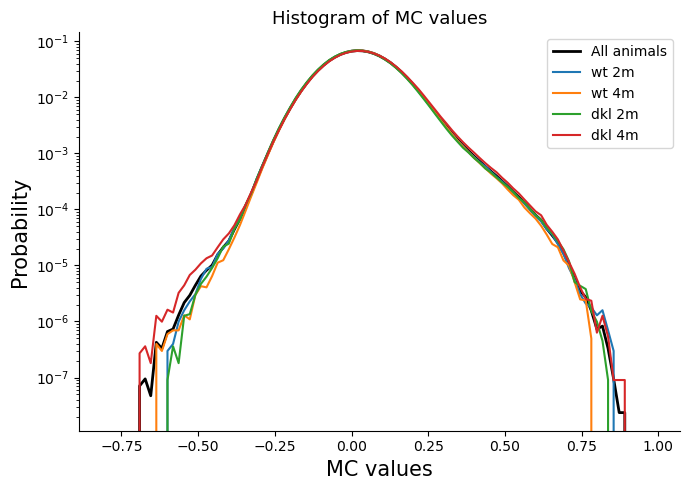

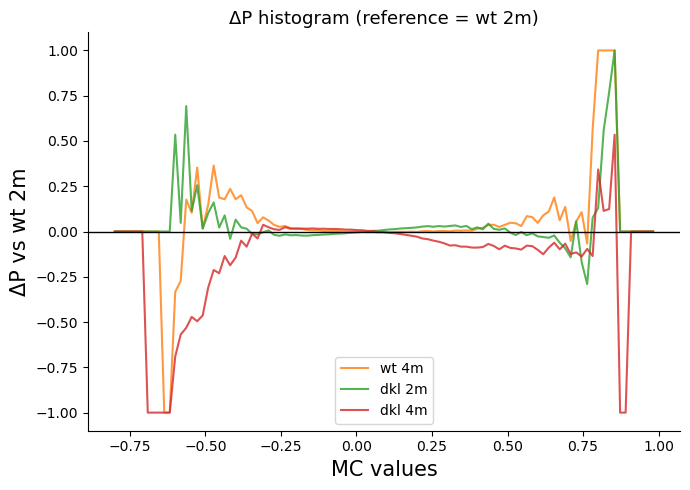

In [ ]:
#!/usr/bin/env python3
"""
MC trimer analysis – modular & reference-safe

Author: Samy
"""

# =============================================================================
# CONFIGURATION
# =============================================================================

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from shared_code.fun_loaddata import load_timeseries_bundle
from shared_code.fun_paths import get_paths
from shared_code.fun_utils import set_figure_params

# ---- plotting defaults ------------------------------------------------------
plt.rcParams.update(
    {
        "axes.spines.right": False,
        "axes.spines.top": False,
        "axes.labelsize": 13,
        "axes.titlesize": 12,
    }
)


SAVE_FIG = set_figure_params(True)

# ---- analysis constants -----------------------------------------------------
REF_GROUP = "wt 2m"
REF_BINS = np.linspace(-0.8, 1.0, 100)

# Authoritative group colors (DO NOT TOUCH elsewhere)
GROUP_COLORS = {
    "wt 2m": "#1f77b4",
    "wt 4m": "#ff7f0e",
    "dkl 2m": "#2ca02c",
    "dkl 4m": "#d62728",
}

# =============================================================================
# DATA LOADING
# =============================================================================

def load_all():
    paths = get_paths(
        dataset_name="ines_abdallah",
        timecourse_folder="Timecourses_updated_03052024",
        cognitive_data_file="ROIs.xlsx",
        anat_labels_file="41_Allen.txt",
    )

    bundle = load_timeseries_bundle(
        paths["preprocessed"] / "ts_and_meta_2m4m.npz",
        paths["preprocessed"] / "grouping_data_oip.pkl",
    )

    mc = np.load(
        paths["mc_mod"]
        / f"mc_allegiance_ref(runs=wt2m_gammaval=1000)=100_"
          f"lag=1_windowsize=7_animals={bundle.n_animals}_regions={bundle.n_regions}.npz",
        allow_pickle=True,
    )

    fig_dir = paths["f_motif"]
    fig_dir.mkdir(exist_ok=True, parents=True)

    return bundle, mc, fig_dir

def normalize_label(label: str) -> str:
    """
    Normalize group labels coming from bundle.label_variables
    to canonical form used in GROUP_COLORS.
    """
    return (
        label
        .strip()
        .lower()
        .replace("dki", "dkl")
        .replace("  ", " ")
    )



# =============================================================================
# MASKS & HELPERS
# =============================================================================

def true_indices_nested(mask_groups):
    """Return list[group][indices]"""
    return [[np.flatnonzero(arr) for arr in group] for group in mask_groups]


def histogram_prob(x, bins):
    h, _ = np.histogram(x, bins=bins)
    p = h / h.sum() if h.sum() > 0 else np.zeros_like(h)
    return p


def delta_p_ref(p_ref, p_other):
    """
    Reference-centered delta probability:
    ΔP = (P_ref - P_other) / (P_ref + P_other)
    """
    dp = (p_ref - p_other) / (p_ref + p_other)
    return np.nan_to_num(dp, nan=0.0)


# =============================================================================
# CORE COMPUTATION
# =============================================================================

def compute_group_histograms(mc_val, indices_mask, labels):
    """
    Returns:
        probs[label] -> probability histogram
    """
    probs = {}

    for idx, inds in enumerate(indices_mask):
        label = normalize_label(labels[idx])


        mc_subset = mc_val[inds, :].ravel()
        probs[label] = histogram_prob(mc_subset, REF_BINS)

    return probs


# =============================================================================
# PLOTTING
# =============================================================================

def plot_histograms(p_all, p_groups, fig_dir):
    fig, ax = plt.subplots(figsize=(7, 5))

    ax.plot(
        REF_BINS[:-1], p_all,
        color="black", lw=2, label="All animals"
    )

    for label, p in p_groups.items():
        ax.plot(
            REF_BINS[:-1], p,
            color=GROUP_COLORS[label],
            label=label,
        )

    ax.set_yscale("log")
    ax.set_xlabel("MC values")
    ax.set_ylabel("Probability")
    ax.set_title("Histogram of MC values")
    ax.legend()

    fig.tight_layout()
    if SAVE_FIG:
        fig.savefig(fig_dir / "mc_histograms.png")


def plot_deltaP(p_ref, p_groups, fig_dir):
    fig, ax = plt.subplots(figsize=(7, 5))

    for label, p in p_groups.items():
        if label == REF_GROUP:
            continue

        ax.plot(
            REF_BINS[:-1],
            delta_p_ref(p_ref, p),
            color=GROUP_COLORS[label],
            alpha=0.8,
            label=label,
        )



    ax.axhline(0, color="black", lw=1)
    ax.set_xlabel("MC values")
    ax.set_ylabel("ΔP vs wt 2m")
    ax.set_title("ΔP histogram (reference = wt 2m)")
    ax.legend()

    fig.tight_layout()
    if SAVE_FIG:
        fig.savefig(fig_dir / "mc_deltaP.png")


# =============================================================================
# MAIN
# =============================================================================

def main():
    bundle, mc, fig_dir = load_all()

    mc_val = mc["mc_val_tril"]
    indices_mask = true_indices_nested(bundle.mask_groups)[2]  # same as before
    labels = bundle.label_variables[2]

    # ---- compute ------------------------------------------------------------
    p_all = histogram_prob(mc_val.ravel(), REF_BINS)
    p_groups = compute_group_histograms(mc_val, indices_mask, labels)

    # ---- plots --------------------------------------------------------------
    plot_histograms(p_all, p_groups, fig_dir)
    plot_deltaP(p_groups[REF_GROUP], p_groups, fig_dir)


if __name__ == "__main__":
    main()



<ipython-input-9-f34381046781>:109: RuntimeWarning: invalid value encountered in divide
  dp = (p_ref - p_other) / (p_ref + p_other)


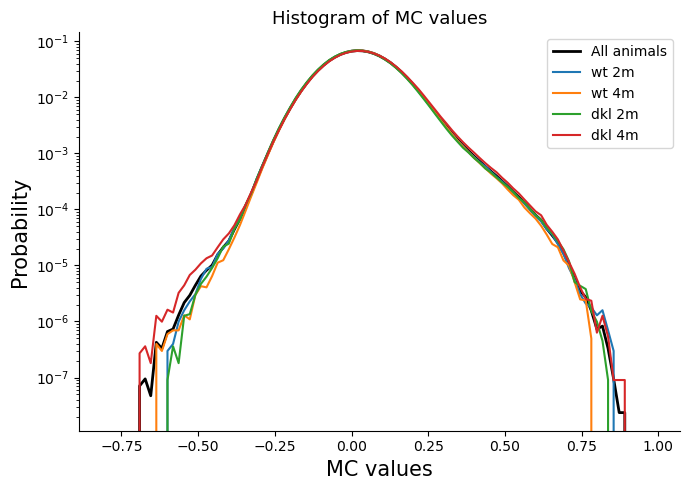

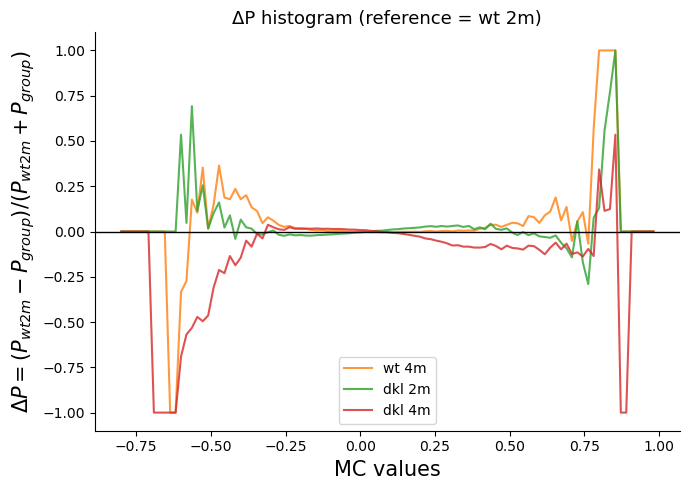

In [ ]:
#!/usr/bin/env python3
"""
MC trimer analysis – modular & reference-safe

Author: Samy
"""

# =============================================================================
# CONFIGURATION
# =============================================================================

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from shared_code.fun_loaddata import load_timeseries_bundle
from shared_code.fun_paths import get_paths
from shared_code.fun_utils import set_figure_params

# ---- plotting defaults ------------------------------------------------------
plt.rcParams.update(
    {
        "axes.spines.right": False,
        "axes.spines.top": False,
        "axes.labelsize": 13,
        "axes.titlesize": 12,
    }
)


SAVE_FIG = set_figure_params(True)

# ---- analysis constants -----------------------------------------------------
REF_GROUP = "wt 2m"
REF_BINS = np.linspace(-0.8, 1.0, 100)

# Authoritative group colors (DO NOT TOUCH elsewhere)
GROUP_COLORS = {
    "wt 2m": "#1f77b4",
    "wt 4m": "#ff7f0e",
    "dkl 2m": "#2ca02c",
    "dkl 4m": "#d62728",
}

# =============================================================================
# DATA LOADING
# =============================================================================

def load_all():
    paths = get_paths(
        dataset_name="ines_abdallah",
        timecourse_folder="Timecourses_updated_03052024",
        cognitive_data_file="ROIs.xlsx",
        anat_labels_file="41_Allen.txt",
    )

    bundle = load_timeseries_bundle(
        paths["preprocessed"] / "ts_and_meta_2m4m.npz",
        paths["preprocessed"] / "grouping_data_oip.pkl",
    )

    mc = np.load(
        paths["mc_mod"]
        / f"mc_allegiance_ref(runs=wt2m_gammaval=1000)=100_"
          f"lag=1_windowsize=7_animals={bundle.n_animals}_regions={bundle.n_regions}.npz",
        allow_pickle=True,
    )

    fig_dir = paths["f_motif"]
    fig_dir.mkdir(exist_ok=True, parents=True)

    return bundle, mc, fig_dir

def normalize_label(label: str) -> str:
    """
    Normalize group labels coming from bundle.label_variables
    to canonical form used in GROUP_COLORS.
    """
    return (
        label
        .strip()
        .lower()
        .replace("dki", "dkl")
        .replace("  ", " ")
    )



# =============================================================================
# MASKS & HELPERS
# =============================================================================

def true_indices_nested(mask_groups):
    """Return list[group][indices]"""
    return [[np.flatnonzero(arr) for arr in group] for group in mask_groups]


def histogram_prob(x, bins):
    h, _ = np.histogram(x, bins=bins)
    p = h / h.sum() if h.sum() > 0 else np.zeros_like(h)
    return p


def delta_p_ref(p_ref, p_other):
    """
    Reference-centered delta probability:
    ΔP = (P_ref - P_other) / (P_ref + P_other)
    """
    dp = (p_ref - p_other) / (p_ref + p_other)
    return np.nan_to_num(dp, nan=0.0)


# =============================================================================
# CORE COMPUTATION
# =============================================================================

def compute_group_histograms(mc_val, indices_mask, labels):
    """
    Returns:
        probs[label] -> probability histogram
    """
    probs = {}

    for idx, inds in enumerate(indices_mask):
        label = normalize_label(labels[idx])


        mc_subset = mc_val[inds, :].ravel()
        probs[label] = histogram_prob(mc_subset, REF_BINS)

    return probs


# =============================================================================
# PLOTTING
# =============================================================================

def plot_histograms(p_all, p_groups, fig_dir):
    fig, ax = plt.subplots(figsize=(7, 5))

    ax.plot(
        REF_BINS[:-1], p_all,
        color="black", lw=2, label="All animals"
    )

    for label, p in p_groups.items():
        ax.plot(
            REF_BINS[:-1], p,
            color=GROUP_COLORS[label],
            label=label,
        )

    ax.set_yscale("log")
    ax.set_xlabel("MC values")
    ax.set_ylabel("Probability")
    ax.set_title("Histogram of MC values")
    ax.legend()

    fig.tight_layout()
    if SAVE_FIG:
        fig.savefig(fig_dir / "mc_histograms.png")


def plot_deltaP(p_ref, p_groups, fig_dir):
    fig, ax = plt.subplots(figsize=(7, 5))

    for label, p in p_groups.items():
        if label == REF_GROUP:
            continue

        ax.plot(
            REF_BINS[:-1],
            delta_p_ref(p_ref, p),
            color=GROUP_COLORS[label],
            alpha=0.8,
            label=label,
        )



    ax.axhline(0, color="black", lw=1)
    ax.set_xlabel("MC values")
    ax.set_ylabel(r"$\Delta P = (P_{wt2m} - P_{group}) / (P_{wt2m} + P_{group})$")

    ax.set_title("ΔP histogram (reference = wt 2m)")
    ax.legend()

    fig.tight_layout()
    if SAVE_FIG:
        fig.savefig(fig_dir / "mc_deltaP.png")


# =============================================================================
# MAIN
# =============================================================================

def main():
    bundle, mc, fig_dir = load_all()

    mc_val = mc["mc_val_tril"]
    indices_mask = true_indices_nested(bundle.mask_groups)[2]  # same as before
    labels = bundle.label_variables[2]

    # ---- compute ------------------------------------------------------------
    p_all = histogram_prob(mc_val.ravel(), REF_BINS)
    p_groups = compute_group_histograms(mc_val, indices_mask, labels)

    # ---- plots --------------------------------------------------------------
    plot_histograms(p_all, p_groups, fig_dir)
    plot_deltaP(p_groups[REF_GROUP], p_groups, fig_dir)


if __name__ == "__main__":
    main()



<ipython-input-10-ee540b7b06e8>:109: RuntimeWarning: invalid value encountered in divide
  dp = (p_ref - p_other) / (p_ref + p_other)


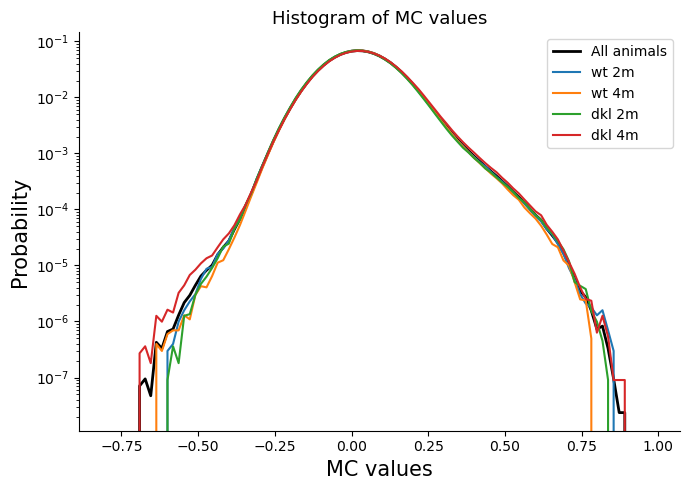

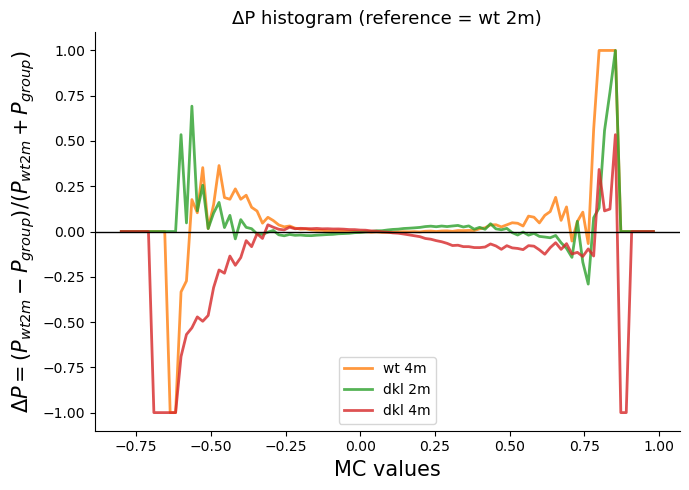

In [ ]:
#!/usr/bin/env python3
"""
MC trimer analysis – modular & reference-safe

Author: Samy
"""

# =============================================================================
# CONFIGURATION
# =============================================================================

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from shared_code.fun_loaddata import load_timeseries_bundle
from shared_code.fun_paths import get_paths
from shared_code.fun_utils import set_figure_params

# ---- plotting defaults ------------------------------------------------------
plt.rcParams.update(
    {
        "axes.spines.right": False,
        "axes.spines.top": False,
        "axes.labelsize": 13,
        "axes.titlesize": 12,
    }
)


SAVE_FIG = set_figure_params(True)

# ---- analysis constants -----------------------------------------------------
REF_GROUP = "wt 2m"
REF_BINS = np.linspace(-0.8, 1.0, 100)

# Authoritative group colors (DO NOT TOUCH elsewhere)
GROUP_COLORS = {
    "wt 2m": "#1f77b4",
    "wt 4m": "#ff7f0e",
    "dkl 2m": "#2ca02c",
    "dkl 4m": "#d62728",
}

# =============================================================================
# DATA LOADING
# =============================================================================

def load_all():
    paths = get_paths(
        dataset_name="ines_abdallah",
        timecourse_folder="Timecourses_updated_03052024",
        cognitive_data_file="ROIs.xlsx",
        anat_labels_file="41_Allen.txt",
    )

    bundle = load_timeseries_bundle(
        paths["preprocessed"] / "ts_and_meta_2m4m.npz",
        paths["preprocessed"] / "grouping_data_oip.pkl",
    )

    mc = np.load(
        paths["mc_mod"]
        / f"mc_allegiance_ref(runs=wt2m_gammaval=1000)=100_"
          f"lag=1_windowsize=7_animals={bundle.n_animals}_regions={bundle.n_regions}.npz",
        allow_pickle=True,
    )

    fig_dir = paths["f_motif"]
    fig_dir.mkdir(exist_ok=True, parents=True)

    return bundle, mc, fig_dir

def normalize_label(label: str) -> str:
    """
    Normalize group labels coming from bundle.label_variables
    to canonical form used in GROUP_COLORS.
    """
    return (
        label
        .strip()
        .lower()
        .replace("dki", "dkl")
        .replace("  ", " ")
    )



# =============================================================================
# MASKS & HELPERS
# =============================================================================

def true_indices_nested(mask_groups):
    """Return list[group][indices]"""
    return [[np.flatnonzero(arr) for arr in group] for group in mask_groups]


def histogram_prob(x, bins):
    h, _ = np.histogram(x, bins=bins)
    p = h / h.sum() if h.sum() > 0 else np.zeros_like(h)
    return p


def delta_p_ref(p_ref, p_other):
    """
    Reference-centered delta probability:
    ΔP = (P_ref - P_other) / (P_ref + P_other)
    """
    dp = (p_ref - p_other) / (p_ref + p_other)
    return np.nan_to_num(dp, nan=0.0)


# =============================================================================
# CORE COMPUTATION
# =============================================================================

def compute_group_histograms(mc_val, indices_mask, labels):
    """
    Returns:
        probs[label] -> probability histogram
    """
    probs = {}

    for idx, inds in enumerate(indices_mask):
        label = normalize_label(labels[idx])


        mc_subset = mc_val[inds, :].ravel()
        probs[label] = histogram_prob(mc_subset, REF_BINS)

    return probs


# =============================================================================
# PLOTTING
# =============================================================================

def plot_histograms(p_all, p_groups, fig_dir):
    fig, ax = plt.subplots(figsize=(7, 5))

    ax.plot(
        REF_BINS[:-1], p_all,
        color="black", lw=2, label="All animals"
    )

    for label, p in p_groups.items():
        ax.plot(
            REF_BINS[:-1], p,
            color=GROUP_COLORS[label],
            label=label,
        )

    ax.set_yscale("log")
    ax.set_xlabel("MC values")
    ax.set_ylabel("Probability")
    ax.set_title("Histogram of MC values")
    ax.legend()

    fig.tight_layout()
    if SAVE_FIG:
        fig.savefig(fig_dir / "mc_histograms.png")


def plot_deltaP(p_ref, p_groups, fig_dir):
    fig, ax = plt.subplots(figsize=(7, 5))

    for label, p in p_groups.items():
        if label == REF_GROUP:
            continue

        ax.plot(
            REF_BINS[:-1],
            delta_p_ref(p_ref, p),
            color=GROUP_COLORS[label],
            alpha=0.8,
            label=label,
            linewidth=2


        )



    ax.axhline(0, color="black", lw=1)
    ax.set_xlabel("MC values")
    ax.set_ylabel(r"$\Delta P = (P_{wt2m} - P_{group}) / (P_{wt2m} + P_{group})$")

    ax.set_title("ΔP histogram (reference = wt 2m)")
    ax.legend()

    fig.tight_layout()
    if SAVE_FIG:
        fig.savefig(fig_dir / "mc_deltaP.png")


# =============================================================================
# MAIN
# =============================================================================

def main():
    bundle, mc, fig_dir = load_all()

    mc_val = mc["mc_val_tril"]
    indices_mask = true_indices_nested(bundle.mask_groups)[2]  # same as before
    labels = bundle.label_variables[2]

    # ---- compute ------------------------------------------------------------
    p_all = histogram_prob(mc_val.ravel(), REF_BINS)
    p_groups = compute_group_histograms(mc_val, indices_mask, labels)

    # ---- plots --------------------------------------------------------------
    plot_histograms(p_all, p_groups, fig_dir)
    plot_deltaP(p_groups[REF_GROUP], p_groups, fig_dir)


if __name__ == "__main__":
    main()



<ipython-input-11-c2d38eabb646>:109: RuntimeWarning: invalid value encountered in divide
  dp = (p_ref - p_other) / (p_ref + p_other)


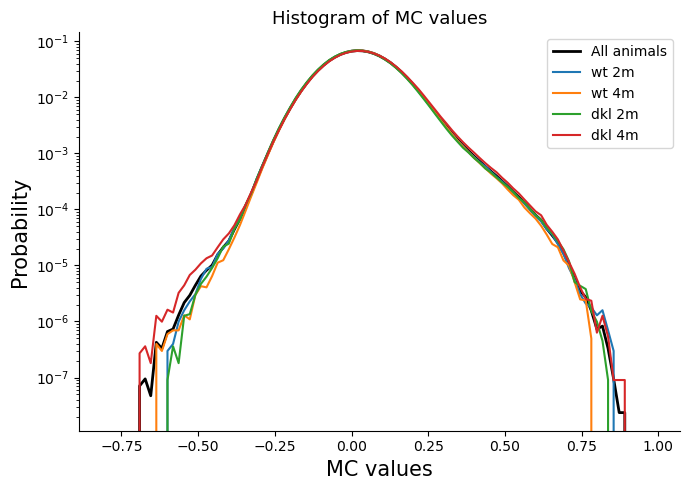

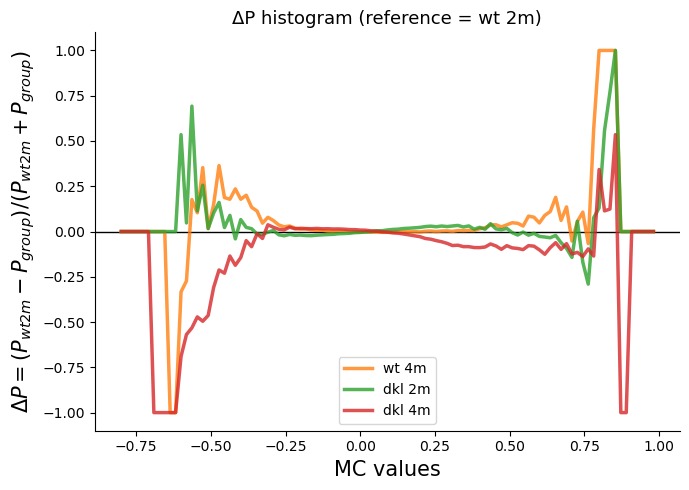

In [ ]:
#!/usr/bin/env python3
"""
MC trimer analysis – modular & reference-safe

Author: Samy
"""

# =============================================================================
# CONFIGURATION
# =============================================================================

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from shared_code.fun_loaddata import load_timeseries_bundle
from shared_code.fun_paths import get_paths
from shared_code.fun_utils import set_figure_params

# ---- plotting defaults ------------------------------------------------------
plt.rcParams.update(
    {
        "axes.spines.right": False,
        "axes.spines.top": False,
        "axes.labelsize": 13,
        "axes.titlesize": 12,
    }
)


SAVE_FIG = set_figure_params(True)

# ---- analysis constants -----------------------------------------------------
REF_GROUP = "wt 2m"
REF_BINS = np.linspace(-0.8, 1.0, 100)

# Authoritative group colors (DO NOT TOUCH elsewhere)
GROUP_COLORS = {
    "wt 2m": "#1f77b4",
    "wt 4m": "#ff7f0e",
    "dkl 2m": "#2ca02c",
    "dkl 4m": "#d62728",
}

# =============================================================================
# DATA LOADING
# =============================================================================

def load_all():
    paths = get_paths(
        dataset_name="ines_abdallah",
        timecourse_folder="Timecourses_updated_03052024",
        cognitive_data_file="ROIs.xlsx",
        anat_labels_file="41_Allen.txt",
    )

    bundle = load_timeseries_bundle(
        paths["preprocessed"] / "ts_and_meta_2m4m.npz",
        paths["preprocessed"] / "grouping_data_oip.pkl",
    )

    mc = np.load(
        paths["mc_mod"]
        / f"mc_allegiance_ref(runs=wt2m_gammaval=1000)=100_"
          f"lag=1_windowsize=7_animals={bundle.n_animals}_regions={bundle.n_regions}.npz",
        allow_pickle=True,
    )

    fig_dir = paths["f_motif"]
    fig_dir.mkdir(exist_ok=True, parents=True)

    return bundle, mc, fig_dir

def normalize_label(label: str) -> str:
    """
    Normalize group labels coming from bundle.label_variables
    to canonical form used in GROUP_COLORS.
    """
    return (
        label
        .strip()
        .lower()
        .replace("dki", "dkl")
        .replace("  ", " ")
    )



# =============================================================================
# MASKS & HELPERS
# =============================================================================

def true_indices_nested(mask_groups):
    """Return list[group][indices]"""
    return [[np.flatnonzero(arr) for arr in group] for group in mask_groups]


def histogram_prob(x, bins):
    h, _ = np.histogram(x, bins=bins)
    p = h / h.sum() if h.sum() > 0 else np.zeros_like(h)
    return p


def delta_p_ref(p_ref, p_other):
    """
    Reference-centered delta probability:
    ΔP = (P_ref - P_other) / (P_ref + P_other)
    """
    dp = (p_ref - p_other) / (p_ref + p_other)
    return np.nan_to_num(dp, nan=0.0)


# =============================================================================
# CORE COMPUTATION
# =============================================================================

def compute_group_histograms(mc_val, indices_mask, labels):
    """
    Returns:
        probs[label] -> probability histogram
    """
    probs = {}

    for idx, inds in enumerate(indices_mask):
        label = normalize_label(labels[idx])


        mc_subset = mc_val[inds, :].ravel()
        probs[label] = histogram_prob(mc_subset, REF_BINS)

    return probs


# =============================================================================
# PLOTTING
# =============================================================================

def plot_histograms(p_all, p_groups, fig_dir):
    fig, ax = plt.subplots(figsize=(7, 5))

    ax.plot(
        REF_BINS[:-1], p_all,
        color="black", lw=2, label="All animals"
    )

    for label, p in p_groups.items():
        ax.plot(
            REF_BINS[:-1], p,
            color=GROUP_COLORS[label],
            label=label,
        )

    ax.set_yscale("log")
    ax.set_xlabel("MC values")
    ax.set_ylabel("Probability")
    ax.set_title("Histogram of MC values")
    ax.legend()

    fig.tight_layout()
    if SAVE_FIG:
        fig.savefig(fig_dir / "mc_histograms.png")


def plot_deltaP(p_ref, p_groups, fig_dir):
    fig, ax = plt.subplots(figsize=(7, 5))

    ax.axhline(0, color="black", lw=1)
    for label, p in p_groups.items():
        if label == REF_GROUP:
            continue

        ax.plot(
            REF_BINS[:-1],
            delta_p_ref(p_ref, p),
            color=GROUP_COLORS[label],
            alpha=0.8,
            label=label,
            linewidth=2.5




        )



    ax.set_xlabel("MC values")
    ax.set_ylabel(r"$\Delta P = (P_{wt2m} - P_{group}) / (P_{wt2m} + P_{group})$")

    ax.set_title("ΔP histogram (reference = wt 2m)")
    ax.legend()

    fig.tight_layout()
    if SAVE_FIG:
        fig.savefig(fig_dir / "mc_deltaP.png")


# =============================================================================
# MAIN
# =============================================================================

def main():
    bundle, mc, fig_dir = load_all()

    mc_val = mc["mc_val_tril"]
    indices_mask = true_indices_nested(bundle.mask_groups)[2]  # same as before
    labels = bundle.label_variables[2]

    # ---- compute ------------------------------------------------------------
    p_all = histogram_prob(mc_val.ravel(), REF_BINS)
    p_groups = compute_group_histograms(mc_val, indices_mask, labels)

    # ---- plots --------------------------------------------------------------
    plot_histograms(p_all, p_groups, fig_dir)
    plot_deltaP(p_groups[REF_GROUP], p_groups, fig_dir)


if __name__ == "__main__":
    main()



Connected to funsy (Python 3.13.3)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Metrics
# ============================================================

def delta_p_weighted(p_ref, p_group):
    """
    Weighted delta-P:
    ((Pref - Pgroup)/(Pref + Pgroup)) * (Pref + Pgroup)
    """
    support = p_ref + p_group
    out = np.zeros_like(p_ref)
    valid = support > 0
    out[valid] = (p_ref[valid] - p_group[valid]) / support[valid]
    return out * support


def delta_p_excess(p_ref, p_group):
    """
    Signed excess probability:
    Pref - Pgroup
    """
    return p_ref - p_group


def cumulative_tail_excess(p_ref, p_group, direction="right"):
    """
    Cumulative signed excess from tail inward.
    """
    diff = p_ref - p_group
    if direction == "right":
        return np.cumsum(diff[::-1])[::-1]
    elif direction == "left":
        return np.cumsum(diff)
    else:
        raise ValueError("direction must be 'left' or 'right'")


# ============================================================
# Plot
# ============================================================

def plot_three_delta_views(p_groups, ref_group, bins, colors):
    p_ref = p_groups[ref_group]
    x = bins[:-1]

    fig, axes = plt.subplots(
        3, 1, figsize=(8, 10), sharex=True
    )

    # -------------------------------
    # Panel 1 — weighted ΔP
    # -------------------------------
    ax = axes[0]
    ax.axhline(0, color="black", lw=1)

    for label, p in p_groups.items():
        if label == ref_group:
            continue
        ax.plot(
            x,
            delta_p_weighted(p_ref, p),
            color=colors[label],
            label=label,
        )

    ax.set_ylabel("Weighted ΔP")
    ax.set_title("Weighted ΔP (bin-wise, support-aware)")
    ax.legend()

    # -------------------------------
    # Panel 2 — signed excess
    # -------------------------------
    ax = axes[1]
    ax.axhline(0, color="black", lw=1)

    for label, p in p_groups.items():
        if label == ref_group:
            continue
        ax.plot(
            x,
            delta_p_excess(p_ref, p),
            color=colors[label],
            label=label,
        )

    ax.set_ylabel("P(wt2m) − P(group)")
    ax.set_title("Signed excess probability")

    # -------------------------------
    # Panel 3 — cumulative right tail
    # -------------------------------
    ax = axes[2]
    ax.axhline(0, color="black", lw=1)

    for label, p in p_groups.items():
        if label == ref_group:
            continue
        ax.plot(
            x,
            cumulative_tail_excess(p_ref, p, direction="right"),
            color=colors[label],
            label=label,
        )

    ax.set_ylabel("Cumulative excess")
    ax.set_xlabel("MC values")
    ax.set_title("Cumulative excess (right tail → inward)")

    fig.tight_layout()
    return fig


# ============================================================
# Call
# ============================================================

fig = plot_three_delta_views(
    p_groups=p_groups,
    ref_group=REF_GROUP,
    bins=REF_BINS,
    colors=GROUP_COLORS,
)

plt.show()



NameError: name 'p_groups' is not defined

[info] Using PATHS_ROOT=/media/samy/Elements2/Proyectos/LauraHarsan


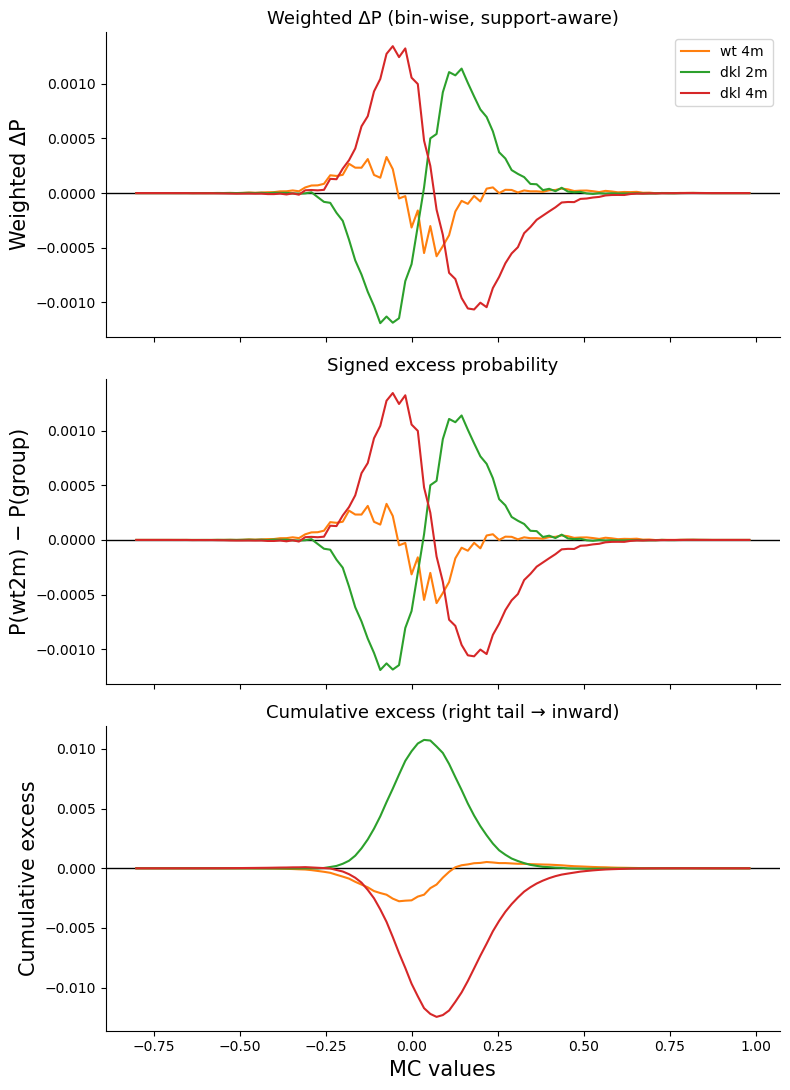

In [ ]:
# ============================================================
# MC tail comparison – three visual metrics (REAL DATA)
# Self-contained, clean-notebook safe
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

from shared_code.fun_loaddata import load_timeseries_bundle
from shared_code.fun_paths import get_paths
from shared_code.fun_utils import set_figure_params

# ============================================================
# CONFIG
# ============================================================

REF_GROUP = "wt 2m"
REF_BINS = np.linspace(-0.8, 1.0, 100)

GROUP_COLORS = {
    "wt 2m": "#1f77b4",
    "wt 4m": "#ff7f0e",
    "dkl 2m": "#2ca02c",
    "dkl 4m": "#d62728",
}

plt.rcParams.update({
    "axes.spines.right": False,
    "axes.spines.top": False,
    "axes.labelsize": 13,
    "axes.titlesize": 12,
})

save_fig = set_figure_params(False)

# ============================================================
# LOAD DATA
# ============================================================

paths = get_paths(
    dataset_name="ines_abdallah",
    timecourse_folder="Timecourses_updated_03052024",
    cognitive_data_file="ROIs.xlsx",
    anat_labels_file="41_Allen.txt",
)

bundle = load_timeseries_bundle(
    paths["preprocessed"] / "ts_and_meta_2m4m.npz",
    paths["preprocessed"] / "grouping_data_oip.pkl",
)

mc = np.load(
    paths["mc_mod"]
    / f"mc_allegiance_ref(runs=wt2m_gammaval=1000)=100_"
      f"lag=1_windowsize=7_animals={bundle.n_animals}_regions={bundle.n_regions}.npz",
    allow_pickle=True,
)

mc_val = mc["mc_val_tril"]   # (animals, edges)

# ============================================================
# HELPERS
# ============================================================

def normalize_label(label):
    return label.strip().lower().replace("dki", "dkl")

def true_indices_nested(mask_groups):
    return [[np.flatnonzero(arr) for arr in group] for group in mask_groups]

def prob_hist(x, bins):
    h, _ = np.histogram(x, bins=bins)
    return h / h.sum() if h.sum() > 0 else np.zeros(len(bins) - 1)

# --- three comparison metrics --------------------------------

def delta_p_weighted(p_ref, p_group):
    support = p_ref + p_group
    out = np.zeros_like(p_ref)
    valid = support > 0
    out[valid] = (p_ref[valid] - p_group[valid]) / support[valid]
    return out * support

def delta_p_excess(p_ref, p_group):
    return p_ref - p_group

def cumulative_tail_excess(p_ref, p_group, direction="right"):
    diff = p_ref - p_group
    if direction == "right":
        return np.cumsum(diff[::-1])[::-1]
    else:
        return np.cumsum(diff)

# ============================================================
# BUILD GROUP HISTOGRAMS (REAL DATA)
# ============================================================

indices_mask = true_indices_nested(bundle.mask_groups)[2]
labels_raw = bundle.label_variables[2]
labels = [normalize_label(l) for l in labels_raw]

p_groups = {}
for inds, label in zip(indices_mask, labels):
    mc_subset = mc_val[inds, :].ravel()
    p_groups[label] = prob_hist(mc_subset, REF_BINS)

assert REF_GROUP in p_groups, f"Reference group '{REF_GROUP}' not found"

# ============================================================
# PLOT: THREE OPTIONS SIDE-BY-SIDE
# ============================================================

x = REF_BINS[:-1]
p_ref = p_groups[REF_GROUP]

fig, axes = plt.subplots(3, 1, figsize=(8, 11), sharex=True)

# ---- 1) Weighted ΔP ----------------------------------------
ax = axes[0]
ax.axhline(0, color="black", lw=1)
for label, p in p_groups.items():
    if label == REF_GROUP:
        continue
    ax.plot(
        x,
        delta_p_weighted(p_ref, p),
        color=GROUP_COLORS[label],
        label=label,
    )
ax.set_ylabel("Weighted ΔP")
ax.set_title("Weighted ΔP (bin-wise, support-aware)")
ax.legend()

# ---- 2) Signed excess probability --------------------------
ax = axes[1]
ax.axhline(0, color="black", lw=1)
for label, p in p_groups.items():
    if label == REF_GROUP:
        continue
    ax.plot(
        x,
        delta_p_excess(p_ref, p),
        color=GROUP_COLORS[label],
    )
ax.set_ylabel("P(wt2m) − P(group)")
ax.set_title("Signed excess probability")

# ---- 3) Cumulative right-tail excess -----------------------
ax = axes[2]
ax.axhline(0, color="black", lw=1)
for label, p in p_groups.items():
    if label == REF_GROUP:
        continue
    ax.plot(
        x,
        cumulative_tail_excess(p_ref, p, direction="right"),
        color=GROUP_COLORS[label],
    )
ax.set_ylabel("Cumulative excess")
ax.set_xlabel("MC values")
ax.set_title("Cumulative excess (right tail → inward)")

fig.tight_layout()
plt.show()



No kernel connected

No kernel connected